# Group Project - Group 14
### Members
1. Shillah Mboya
2. Salim Mananda
3. Donald Kipsoi
4. Ngamau Mbau

![Waste sorting](https://images.unsplash.com/photo-1532996122724-e3c354a0b15b?w=1200&h=220&fit=crop)

# EcoSort Waste Management Assistant for Metro City

### Sorting household waste from photos and descriptions, then telling residents exactly what city policy says to do with it

## Overview

**Bottom line up front.** The text classifier sorts written descriptions into the nine waste categories with 100% accuracy on held-out data, but 85% once the give-away words are hidden, and the 85% is the better guide to how real residents will write. The image classifier reaches 0.7958 test accuracy on held-out photos, and the hardest category to recognise is Miscellaneous Trash (recall 0.635). When it is told the category, the retrieval step finds the right city policy every time. When it has to find the policy from a description alone it is much weaker (section 4.1), which is why the assistant only retrieves after classification and flags low-confidence answers. The recycling generator is flan-t5-small, fine-tuned on policy-grounded examples and tested on categories it never saw during fine-tuning; every answer also carries the word-for-word policy checklist and the source policy documents.

**What we built.** For the photos: MobileNetV2 transfer learning with augmentation, dropout, class weights, a comparison of three head designs, and a second fine-tuning phase. For the descriptions: Naive Bayes, Random Forest and Logistic Regression on TF-IDF features, dense embeddings, tuning on a separate validation set, and a stress test that hides the give-away words. For the instructions: an index of the 14 policy documents plus the 45 category disposal instructions, tuned retrieval, and a fine-tuned generative model that writes from the retrieved text only. For the assistant: confidence scores, a human-review flag, source citations and the full policy documents, error handling for bad input, and a feedback log.

**Caveats to read before drawing conclusions.**
1. The 100% text accuracy is mostly a property of the data. Over half the descriptions contain their own category word, and when those words are removed accuracy falls to 85%.
2. Two columns in the description file give the answer away and must never be used as features, and 230 descriptions carry a label that the city's own policy contradicts, such as light bulbs labelled Glass when the Glass policy bans them.
3. In the recorded run, fine-tuning the image backbone lowered validation accuracy (0.8043 to 0.7894), and the model used for the final results is the fine-tuned one.
4. There are only nine policy documents' worth of text to fine-tune the generator on, so fine-tuning teaches it the answer format and to copy from the policy it is shown. It does not teach it new facts. We test that on held-out categories, and the policy checklist is always attached so a poor summary cannot hide a rule.

*Numbers quoted in the written commentary come from the run recorded in this notebook. Re-training changes them slightly, and the evaluation cells print the current values.*

## Setup and Data Loading

In [9]:
%pip install transformers sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Standard Python tools

import re
import json
import random
import time
from pathlib import Path
from collections import Counter

# Data handling, plotting and images

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn: text features, text models, evaluation and retrieval

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow and Keras: the image model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Hugging Face transformers: the pretrained language model for the recycling instructions
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

sns.set_style('whitegrid')

# Set random seeds so results can be reproduced
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [11]:
# File location
data_dir = Path(r'C:\Moringa\Assignments\Module V\Waste Management\realwaste\realwaste-main\RealWaste')
policy_path = r'C:\Moringa\Assignments\Module V\Waste Management\realwaste\waste_policy_documents.json'

In [12]:
# Load the waste description data

desc_df = pd.read_csv('waste_descriptions.csv')

print('Shape:', desc_df.shape)
print('Columns:', list(desc_df.columns))
desc_df.head()

Shape: (5000, 5)
Columns: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


In [13]:
# Load the policy documents

from pathlib import Path

# Get the folder where the notebook is located
notebook_folder = Path.cwd()

# Path to the policy document in the same folder
policy_path = notebook_folder / "waste_policy_documents.json"

# Check that the file exists
if not policy_path.exists():
    raise FileNotFoundError(
        f"Policy document not found at:\n{policy_path}"
    )

# Load the policy documents
with open(policy_path, encoding="utf-8") as f:
    policy_docs = json.load(f)

print("Number of policy documents:", len(policy_docs))
print("Fields in each document:", list(policy_docs[0].keys()))

Number of policy documents: 14
Fields in each document: ['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']


## 1. Data Preparation

Before building any model we look at all three data sources: the photos, the written descriptions, and the policy documents. Each one has a quirk that shapes a later decision, so we record what we find as we go.

### 1.1 The RealWaste photos

In [14]:
# The waste categories are inside the RealWaste folder
data_dir = Path.cwd() / "realwaste" / "realwaste-main" / "RealWaste"

# Check that the folder exists
if not data_dir.exists():
    raise FileNotFoundError(
        f"RealWaste folder not found:\n{data_dir}"
    )

print("Reading waste categories from:")
print(data_dir)
print()

# Count images in each waste category
category_names = []
image_totals = []
image_counts = {}

for folder in sorted(data_dir.iterdir()):

    # Only process folders
    if folder.is_dir():

        # Count common image formats
        n_images = (
            len(list(folder.glob("*.jpg"))) +
            len(list(folder.glob("*.jpeg"))) +
            len(list(folder.glob("*.png"))) +
            len(list(folder.glob("*.JPG"))) +
            len(list(folder.glob("*.JPEG"))) +
            len(list(folder.glob("*.PNG")))
        )

        category_names.append(folder.name)
        image_totals.append(n_images)
        image_counts[folder.name] = n_images

# Create DataFrame
image_count_df = pd.DataFrame({
    "category": category_names,
    "images": image_totals
})

# Sort from largest to smallest
image_count_df = image_count_df.sort_values(
    "images",
    ascending=False
)

print(image_count_df.to_string(index=False))
print()

# Total number of images
total_images = image_count_df["images"].sum()

print("Total images:", int(total_images))

# Calculate imbalance ratio
if len(image_count_df) > 0 and image_count_df["images"].min() > 0:
    ratio = (
        image_count_df["images"].max() /
        image_count_df["images"].min()
    )

    print(f"Largest category is {ratio:.1f} times the smallest")

Reading waste categories from:
d:\Moringa Data Science\Mod 5\Waste Management_Summ Lab_Group Work\Waste_Management_Lab-Group_14-\realwaste\realwaste-main\RealWaste

           category  images
            Plastic    1842
              Metal    1580
              Paper    1000
Miscellaneous Trash     990
          Cardboard     922
         Vegetation     872
              Glass     840
      Food Organics     822
      Textile Trash     636

Total images: 9504
Largest category is 2.9 times the smallest


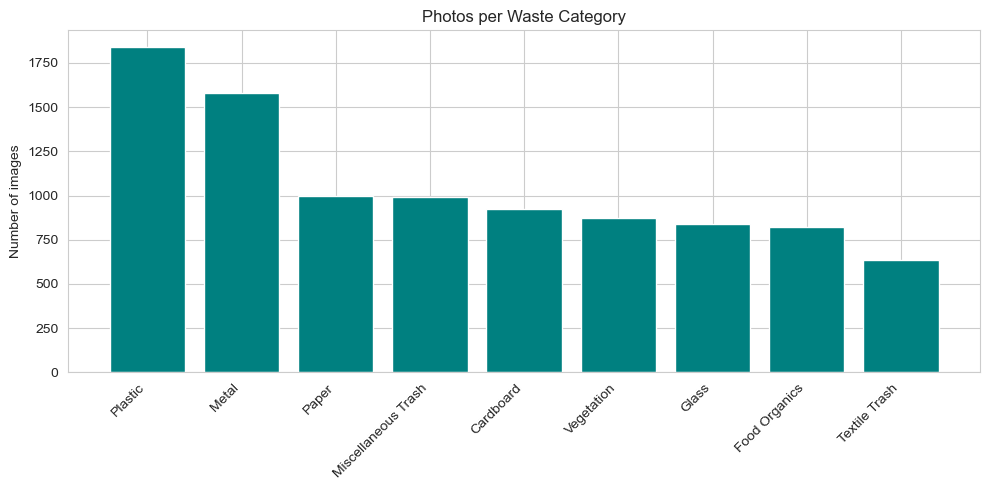

In [15]:
# Plot the category sizes

plt.figure(figsize=(10, 5))
plt.bar(image_count_df['category'], image_count_df['images'], color='teal')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of images')
plt.title('Photos per Waste Category')
plt.tight_layout()
plt.show()

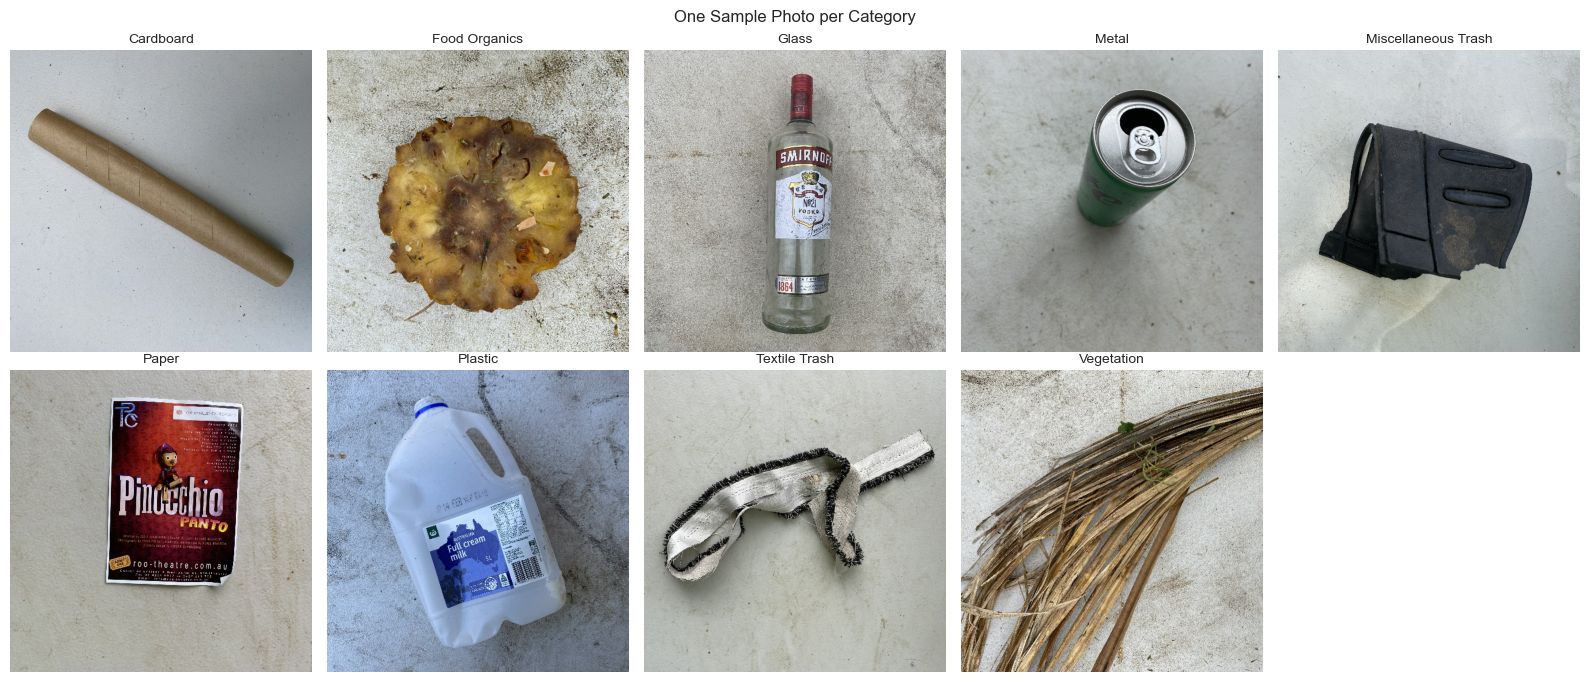

In [16]:
# Show one example photo from each waste category so we can see what the model will learn from

categories = sorted(category_names)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i in range(len(axes)):
    axes[i].axis('off')

    if i < len(categories):
        category_folder = data_dir / categories[i]
        image_files = list(category_folder.glob('*.jpg')) + list(category_folder.glob('*.png'))

        if len(image_files) > 0:
            axes[i].imshow(Image.open(image_files[0]))
            axes[i].set_title(categories[i], fontsize=10)
        else:
            axes[i].set_title(categories[i] + ' (no images)', fontsize=10)

plt.suptitle('One Sample Photo per Category')
plt.tight_layout()
plt.show()

Image sizes found in the sample:
width  height
524    524       180
dtype: int64

Average brightness by category (0 is black, 255 is white):
category
Cardboard              156.1
Food Organics          153.2
Glass                  157.5
Metal                  157.4
Miscellaneous Trash    166.2
Paper                  154.5
Plastic                151.0
Textile Trash          161.3
Vegetation             151.8
Name: brightness, dtype: float64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10036\49121592.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=image_info, x='category', y='brightness', palette='viridis')


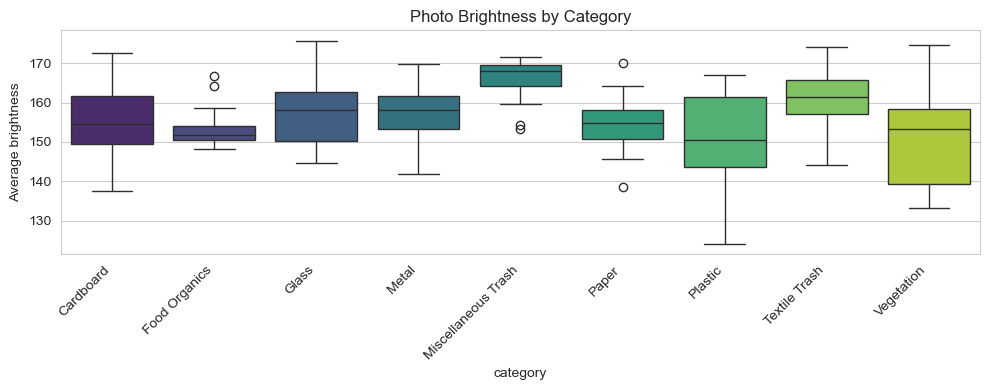

In [17]:
# Look at image size and brightness for a sample of photos in each category.
# Brightness tells us whether some categories were photographed in different lighting, which a model could learn as a shortcut instead of the material.

image_rows = []

for folder in sorted(data_dir.iterdir()):
    if not folder.is_dir():
        continue
    files = list(folder.glob('*.jpg'))[:20]
    for path in files:
        img = Image.open(path)
        width, height = img.size
        brightness = np.array(img.convert('L')).mean()
        image_rows.append({'category': folder.name, 'width': width,
                           'height': height, 'brightness': brightness})

image_info = pd.DataFrame(image_rows)
print('Image sizes found in the sample:')
print(image_info.groupby(['width', 'height']).size())
print()
print('Average brightness by category (0 is black, 255 is white):')
print(image_info.groupby('category')['brightness'].mean().round(1))

plt.figure(figsize=(10, 4))
sns.boxplot(data=image_info, x='category', y='brightness', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average brightness')
plt.title('Photo Brightness by Category')
plt.tight_layout()
plt.show()

**What will make this classification hard.** From the counts, the sample photos and the brightness table above:

- **Look-alike materials.** Paper and cardboard are both flat, matte and beige. Plastic, glass and metal are all shiny, and clear or reflective items lose their texture in a photo.
- **Miscellaneous Trash has no visual signature.** It is defined by what it is *not*, so it holds toys, tools, pens and broken items. We expect it to be the weakest class.
- **Imbalance.** Plastic has 921 photos and Textile Trash 318, a ratio of 2.9 to 1. Accuracy alone can hide a weak small class, so we use class weights and judge by per-class recall.
- **Image quality and background.** Every sampled photo is 524 by 524 pixels, and average brightness differs by only about 15 grey levels between categories (151 to 166), so lighting is not an obvious shortcut. But the photos were captured at a real waste facility under one setup, so a resident's phone photo, with a different background, lighting and framing, may do worse than our test scores suggest. Shrinking to 224 by 224 also loses detail on small items.

### 1.2 The written descriptions

In [18]:
# Basic checks on the description file

print('Missing values per column:')
print(desc_df.isnull().sum())
print()
print('Duplicate descriptions:', desc_df['description'].duplicated().sum())
print()
print('Descriptions per category:')
print(desc_df['category'].value_counts())

Missing values per column:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64

Duplicate descriptions: 61

Descriptions per category:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


In [19]:
# Description length and vocabulary

desc_df['word_count'] = desc_df['description'].str.split().str.len()

all_words = []
for text in desc_df['description']:
    for word in text.lower().split():
        all_words.append(word)

print('Words per description:')
print(desc_df['word_count'].describe().round(2))
print()
print('Total words:', len(all_words))
print('Distinct words:', len(set(all_words)))
print()

print('Ten random descriptions:')
for text in random.sample(list(desc_df['description']), 10):
    print('  -', text)

Words per description:
count    5000.00
mean        4.85
std         1.55
min         1.00
25%         4.00
50%         5.00
75%         6.00
max        10.00
Name: word_count, dtype: float64

Total words: 24270
Distinct words: 305

Ten random descriptions:
  - gold glass candle holder containing residue
  - clean fun-sized purple Premium food container with contents
  - new pink Artisanal nut shells
  - multi-colored printer paper
  - wet black plastic cutlery
  - used brown tree bark
  - plastic Local polyester jacket with contents
  - new Brand B beverage carrier containing residue
  - fun-sized red bamboo tablecloth with contents
  - empty yellow houseplant partially filled


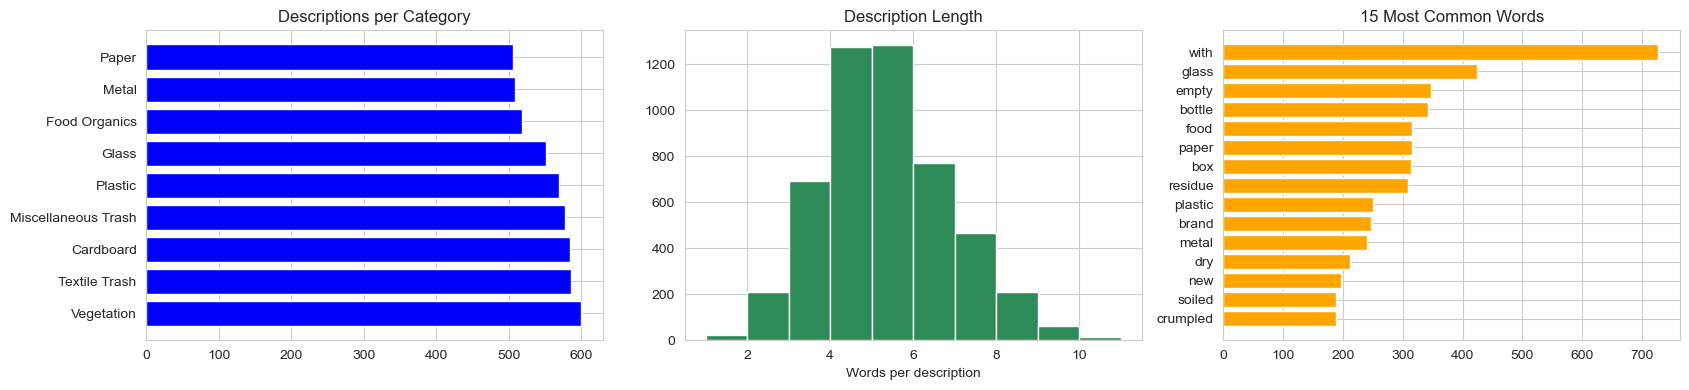

In [20]:
# Plot category sizes, description length and the most common words

common_words = Counter(all_words).most_common(15)
top_words = []
top_counts = []
for word, count in common_words:
    top_words.append(word)
    top_counts.append(count)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

category_counts = desc_df['category'].value_counts()
axes[0].barh(category_counts.index, category_counts.values, color='blue')
axes[0].set_title('Descriptions per Category')

axes[1].hist(desc_df['word_count'], bins=range(1, 12), color='seagreen', edgecolor='white')
axes[1].set_xlabel('Words per description')
axes[1].set_title('Description Length')

axes[2].barh(top_words[::-1], top_counts[::-1], color='orange')
axes[2].set_title('15 Most Common Words')

plt.tight_layout()
plt.show()

In [21]:
# Check whether any column other than the description gives the answer away, if each value of a column belongs to only one category, the column is a label leak.

for column in ['material_composition', 'common_confusion', 'disposal_instruction']:
    rows_with_value = desc_df[desc_df[column].notna()]
    categories_per_value = rows_with_value.groupby(column)['category'].nunique()
    print(f'{column:22s} distinct values: {rows_with_value[column].nunique():3d}   '
          f'most categories sharing one value: {categories_per_value.max()}')

print()
print('A maximum of 1 means every value points to exactly one category.')

material_composition   distinct values:   9   most categories sharing one value: 1
common_confusion       distinct values:   9   most categories sharing one value: 1
disposal_instruction   distinct values:  44   most categories sharing one value: 2

A maximum of 1 means every value points to exactly one category.


In [22]:
# How many descriptions contain an obvious word for their own category?

give_away_words = {
    'Glass': ['glass'],
    'Metal': ['metal', 'aluminum', 'tin', 'can', 'foil', 'steel'],
    'Paper': ['paper', 'newspaper', 'magazine', 'envelope'],
    'Cardboard': ['cardboard', 'carton', 'box'],
    'Plastic': ['plastic', 'bottle', 'container', 'wrapper'],
    'Vegetation': ['grass', 'leaf', 'leaves', 'branch', 'plant', 'garden', 'weed', 'flower'],
    'Food Organics': ['food', 'fruit', 'vegetable', 'apple', 'banana', 'meat', 'bread', 'egg'],
    'Textile Trash': ['cloth', 'fabric', 'textile', 'shirt', 'towel', 'carpet', 'tablecloth'],
    'Miscellaneous Trash': ['misc', 'trash'],
}

hits = 0
for index, row in desc_df.iterrows():
    text = row['description'].lower()
    for word in give_away_words[row['category']]:
        if word in text:
            hits = hits + 1
            break

print(f'Descriptions containing a give-away word for their own category: '
      f'{hits} of {len(desc_df)} ({hits / len(desc_df):.1%})')
print()
print('Examples:')
for category in ['Glass', 'Paper', 'Vegetation']:
    examples = desc_df[desc_df['category'] == category]['description'].head(2).tolist()
    print(f'  {category}: {examples}')

Descriptions containing a give-away word for their own category: 2878 of 5000 (57.6%)

Examples:
  Glass: ['folded glass bottle leaking', 'broken glass container']
  Paper: ['wrinkled newspaper', 'new tissue paper']
  Vegetation: ['clean red grass clippings', 'small striped Organic fallen leaves']


### 1.3 The policy documents

In [23]:
# Summarise each policy document

policy_rows = []
for doc in policy_docs:
    policy_rows.append({
        'policy_id': doc['policy_id'],
        'policy_type': doc['policy_type'],
        'categories': ', '.join(doc['categories_covered']),
        'characters': len(doc['document_text'])
    })

policy_df = pd.DataFrame(policy_rows)
print(policy_df.to_string(index=False))

 policy_id                              policy_type                                             categories  characters
         1       Textile Trash Recycling Guidelines                                          Textile Trash         688
         2               Glass Recycling Guidelines                                                  Glass         571
         3       Food Organics Recycling Guidelines                                          Food Organics         638
         4             Plastic Recycling Guidelines                                                Plastic         655
         5          Vegetation Recycling Guidelines                                             Vegetation         620
         6           Cardboard Recycling Guidelines                                              Cardboard         606
         7               Metal Recycling Guidelines                                                  Metal         664
         8               Paper Recycling Guideli

In [24]:
# How often is each category covered, and does every category have a policy?

coverage = Counter()
for doc in policy_docs:
    for category in doc['categories_covered']:
        coverage[category] = coverage[category] + 1

print('Policy documents covering each category:')
for category, count in coverage.most_common():
    print(f'  {category:22s} {count}')

missing = set(desc_df['category'].unique()) - set(coverage.keys())
print()
print('Categories with no policy at all:', missing if missing else 'none')

Policy documents covering each category:
  Vegetation             4
  Metal                  4
  Miscellaneous Trash    4
  Textile Trash          3
  Glass                  3
  Plastic                3
  Cardboard              3
  Food Organics          2
  Paper                  1

Categories with no policy at all: none


In [25]:
# Compare how two policies word the same idea.
# Most use "Non-Acceptable Items", but the Miscellaneous Trash policy uses different headings.

for policy_number in [1, 8]:
    doc = policy_docs[policy_number]
    print(f"--- {doc['policy_type']} ---")
    for line in doc['document_text'].split('\n'):
        if line.strip().endswith(':'):
            print('  heading:', line.strip())
    print()

--- Glass Recycling Guidelines ---
  heading: Acceptable Items:
  heading: Non-Acceptable Items:
  heading: Collection Method:
  heading: Preparation Instructions:
  heading: Benefits:

--- Miscellaneous Trash Recycling Guidelines ---
  heading: Items That Cannot Be Recycled:
  heading: Special Handling Items:
  heading: Waste Reduction Tips:
  heading: Benefits:



In [26]:
# Do the description labels agree with the city's own rules?
# The category label records the MATERIAL, but each policy lists items of that material that must NOT go in its bin. 
# These terms are copied from the policies' not-accepted lists.

POLICY_EXCLUSIONS = {
    'Glass': ['light bulb', 'bulb', 'mirror', 'window', 'drinking glass', 'pyrex', 'ceramic', 'pottery'],
    'Textile Trash': ['carpet', 'rug', 'footwear', 'shoe'],
    'Plastic': ['bag', 'film', 'polystyrene', 'foam'],
    'Cardboard': ['waxed', 'foam insert', 'packing peanut'],
    'Paper': ['paper towel', 'napkin', 'receipt', 'waxed'],
    'Metal': ['paint can', 'pressurized'],
    'Food Organics': ['cooking oil', 'grease'],
    'Vegetation': ['soil', 'dirt', 'rock', 'gravel', 'treated wood'],
}

def excluded_item_mentioned(text, category):
    # Whole-word match, allowing a plural "s". Plain substring matching would wrongly
    # find "rug" inside "corrugated" and "dirt" inside "dirty".
    for term in POLICY_EXCLUSIONS.get(category, []):
        if re.search(r'\b' + term + r's?\b', text.lower()):
            return term
    return None


conflict_count = 0
conflict_rows = []
for index, row in desc_df.iterrows():
    term = excluded_item_mentioned(row['description'], row['category'])
    if term is not None:
        conflict_count = conflict_count + 1
        conflict_rows.append({'category': row['category'], 'banned item': term})

print(f'Descriptions whose label the policy contradicts: {conflict_count} '
      f'({conflict_count / len(desc_df):.1%})')
print()
print(pd.DataFrame(conflict_rows).value_counts().to_string())

Descriptions whose label the policy contradicts: 230 (4.6%)

category       banned item   
Textile Trash  carpet            39
Glass          light bulb        33
               window            28
Textile Trash  rug               26
Glass          drinking glass    25
Paper          paper towel       24
Plastic        bag               22
Glass          mirror            19
Paper          receipt           14


The description file is clean, with no missing descriptions, and the nine categories are close to balanced, ranging from 506 to 600 examples each. That balance means accuracy is a fair headline metric for the text model, which it would not be for the photos if their folders turn out uneven.

Two columns leak the label. Every value of material composition and of common confusion belongs to exactly one category, so a model given either column would score perfectly by memorising a lookup table. A resident typing into the app will never supply those fields, so we use the description text only.

About half the descriptions contain their own category word. "Broken glass container" is Glass and "wrinkled newspaper" is Paper. This makes the text task much easier than real resident writing would be, and in Part Two we measure how much of the model's accuracy survives when those words are hidden.

The policy documents cover all nine categories, but not in a uniform way. Nine documents each describe a single category, five describe several at once, and the Miscellaneous Trash policy uses different section headings from the rest, such as "Items That Cannot Be Recycled" instead of "Non-Acceptable Items". Any code that reads the policies by heading name has to allow for that, and in Part Three it does.

The labels and the policies disagree for 230 descriptions, about 4.6% of the file. Light bulbs, mirrors, window glass and drinking glasses are labelled Glass, yet the Glass policy bans all four. Carpets and rugs are labelled Textile Trash, yet the Textile policy bans them, and the same happens with plastic bags, paper towels and receipts. The label answers "what is it made of", while the resident needs "which bin does it go in". A model trained on these labels will confidently send a light bulb to the glass bin, so the assistant in Part Four checks every description against these exclusions and warns the resident when one applies.

### 1.4 Data pipelines and splits

We prepare each data source for its model here, so the three parts below can start straight from modelling. The image code is the version provided with the lab.

In [27]:

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure

num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders

class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images

image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# 80% training, 20% held out

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=True)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=True)

# Split the held out 20% in half: 10% validation for tuning, 10% test for the final score

val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


The image split is 80% training, 10% validation and 10% test. Validation data guides our tuning choices, so a score measured on it is slightly optimistic. Keeping a separate test set that the model never influences gives us an honest final number.

In [28]:
# Text cleaning function for the descriptions

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


desc_df['clean_description'] = desc_df['description'].apply(clean_text)

print('Before:', desc_df['description'].iloc[7])
print('After: ', desc_df['clean_description'].iloc[7])

Before: clean red grass clippings
After:  clean red grass clippings


In [29]:
# Split the descriptions 70% train, 15% validation, 15% test.
# We only use the description column, because the other columns leak the label.

X_text = desc_df['clean_description']
y_text = desc_df['category']

X_text_train, X_temp, y_text_train, y_temp = train_test_split(
    X_text, y_text, test_size=0.30, random_state=42, stratify=y_text)

X_text_val, X_text_test, y_text_val, y_text_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('Training descriptions:  ', len(X_text_train))
print('Validation descriptions:', len(X_text_val))
print('Test descriptions:      ', len(X_text_test))

Training descriptions:   3500
Validation descriptions: 750
Test descriptions:       750


In [30]:
# Turn the text into numbers with TF-IDF.
# Word pairs (bigrams) are included because "glass jar" is more telling than either word alone.
# The vectoriser learns its vocabulary from the training set only, so no test words leak in.

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_val_tfidf = tfidf.transform(X_text_val)
X_test_tfidf = tfidf.transform(X_text_test)

print('TF-IDF training matrix:', X_train_tfidf.shape)
print('Vocabulary size:', len(tfidf.vocabulary_))

TF-IDF training matrix: (3500, 2391)
Vocabulary size: 2391


In [31]:
# Create dense word embeddings from the TF-IDF matrix using TruncatedSVD.
# This squeezes thousands of sparse word columns into 100 dense dimensions where related words end up close together.

svd = TruncatedSVD(n_components=100, random_state=42)

X_train_embed = svd.fit_transform(X_train_tfidf)
X_val_embed = svd.transform(X_val_tfidf)
X_test_embed = svd.transform(X_test_tfidf)

print('Embedding matrix:', X_train_embed.shape)
print(f'Share of TF-IDF variation kept in 100 dimensions: {svd.explained_variance_ratio_.sum():.1%}')

Embedding matrix: (3500, 100)
Share of TF-IDF variation kept in 100 dimensions: 38.7%


In [32]:
# Word-level embeddings.
# Every column of the SVD component matrix is a 100-dimensional vector for one TF-IDF term (a word or a word pair), so we get
# word embeddings from the same decomposition. Related words should sit close together.
term_vectors = svd.components_.T
term_names = tfidf.get_feature_names_out()
term_index = {term: i for i, term in enumerate(term_names)}

def nearest_terms(term, n=6):
    similarity = cosine_similarity(term_vectors[term_index[term]].reshape(1, -1), term_vectors)[0]
    best = np.argsort(similarity)[::-1][1:n + 1]
    return [term_names[i] for i in best]

for word in ['glass', 'carpet', 'newspaper', 'banana', 'leaves']:
    if word in term_index:
        print(f'{word:10s} -> {nearest_terms(word)}')

glass      -> ['glass vase', 'vase', 'glass jar', 'jar', 'pitcher', 'glass pitcher']
carpet     -> ['carpet', 'piece', 'piece with', 'red carpet', 'designer carpet', 'piece leaking']
newspaper  -> ['budget newspaper', 'new', 'newspaper with', 'wrinkled medium', 'new medium', 'wrinkled personal']
banana     -> ['banana', 'supermarket banana', 'brown banana', 'organic banana', 'peel', 'peel empty']
leaves     -> ['fallen', 'fallen leaves', 'imported fallen', 'striped fallen', 'organic fallen', 'leaves with']


In [33]:
# Prepare documents for retrieval.
# We split every policy into paragraph-sized chunks so a search returns a focused passage.

rag_chunks = []

for doc in policy_docs:
    paragraphs = re.split(r'\n\n+', doc['document_text'])
    for paragraph in paragraphs:
        paragraph = paragraph.strip()
        if len(paragraph) < 20:
            continue
        rag_chunks.append({
            'source': f"Policy {doc['policy_id']}: {doc['policy_type']}",
            'categories': doc['categories_covered'],
            'text': paragraph
        })

for category in sorted(desc_df['category'].unique()):
    instructions = desc_df[desc_df['category'] == category]['disposal_instruction'].unique()
    for instruction in instructions:
        rag_chunks.append({
            'source': f'{category} disposal instructions',
            'categories': [category],
            'text': instruction
        })

print('Policy chunks and disposal instructions:', len(rag_chunks))
print()
print('Example chunk:')
print(rag_chunks[1]['source'])
print(rag_chunks[1]['text'][:200])

Policy chunks and disposal instructions: 126

Example chunk:
Policy 1: Textile Trash Recycling Guidelines
Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals


In [34]:
# Create TF-IDF embeddings for every chunk and build the retrieval index.
# We add the source title and category names to each chunk's searchable text, so a search for "Glass" can match the glass policy even 
# when a paragraph never repeats the word.

chunk_texts = []
for chunk in rag_chunks:
    chunk_texts.append(chunk['source'] + ' ' + ' '.join(chunk['categories']) + ' ' + chunk['text'])

rag_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), sublinear_tf=True)
chunk_matrix = rag_vectorizer.fit_transform(chunk_texts)

print('Retrieval index shape:', chunk_matrix.shape)

Retrieval index shape: (126, 1154)


The descriptions are split 3,500 for training, 750 for validation and 750 for testing, with the same category mix in each. The validation set is what we tune on in Part Two, so the test score at the end is untouched by any of our choices.

The 100 dimension embeddings keep only about 39% of the variation in the TF-IDF matrix. That is a warning sign before we even train on them: squeezing short, keyword driven descriptions into a small dense space may throw away exactly the words that identify the category. Part Two tests this directly.

The retrieval index holds 126 searchable pieces: 81 policy paragraphs and 45 disposal instructions, five for each category.

## 2. Part One: Identifying Waste from Resident Photos

Residents will photograph an item and ask what to do with it. This section builds an image classifier for the nine RealWaste categories using transfer learning, because training a network from scratch on a few thousand photos would badly overfit.

In [35]:
# Preprocessing and augmentation.
# We add random flips, rotations and zooms so the model sees a slightly different version of each photo in every epoch. 
# This makes it harder to memorise individual pictures.

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name='augmentation')

# MobileNetV2 was trained on pixels scaled to the range -1 to 1, so we normalise the same way. Using a different scale would confuse the pretrained weights.

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
print('Augmentation and MobileNetV2 normalisation ready')

Augmentation and MobileNetV2 normalisation ready


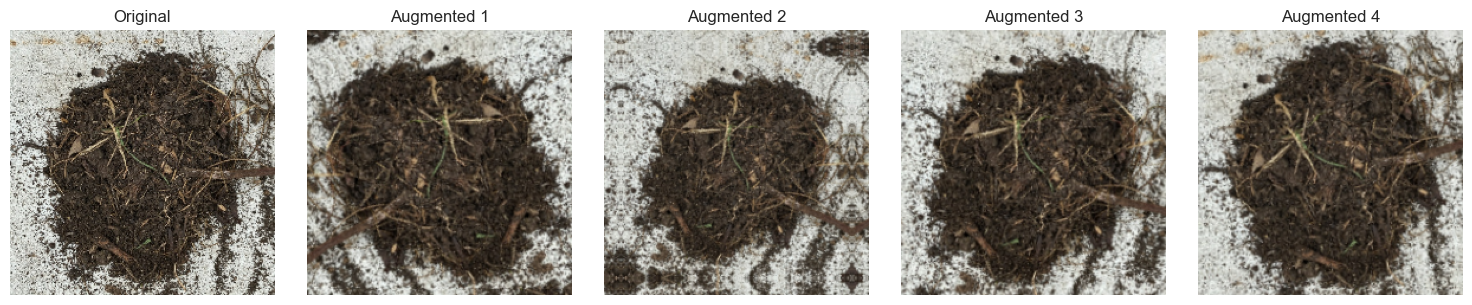

In [36]:
# Preview what augmentation does to one training photo

for images, labels in train_ds.take(1):
    first_image = images[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(first_image.numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 5):
    augmented = data_augmentation(tf.expand_dims(first_image, 0), training=True)
    axes[i].imshow(augmented[0].numpy().astype('uint8'))
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [37]:
# Class weights so that rare categories count more during training.
# Without them a model can score well by leaning towards the biggest folders.

label_list = []
for index in range(len(class_names)):
    label_list = label_list + [index] * image_counts[class_names[index]]

weights = compute_class_weight(class_weight='balanced',
                               classes=np.arange(len(class_names)),
                               y=np.array(label_list))

class_weights = {}
for index in range(len(class_names)):
    class_weights[index] = weights[index]
    print(f'{class_names[index]:22s} images={image_counts[class_names[index]]:4d}  weight={weights[index]:.2f}')

Cardboard              images= 922  weight=1.15
Food Organics          images= 822  weight=1.28
Glass                  images= 840  weight=1.26
Metal                  images=1580  weight=0.67
Miscellaneous Trash    images= 990  weight=1.07
Paper                  images=1000  weight=1.06
Plastic                images=1842  weight=0.57
Textile Trash          images= 636  weight=1.66
Vegetation             images= 872  weight=1.21


In [38]:
# Build the transfer learning model.
# MobileNetV2 is small (about 3.5 million weights) and fast, so it could later run on a phone, 
# and its ImageNet training already recognises textures like paper, metal and glass.

def build_cnn(hidden_units=[128], dropout_rate=0.3, learning_rate=0.001):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,   
        weights='imagenet')
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Custom head: one or more dense layers, each followed by dropout
    
    for units in hidden_units:
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=keras.regularizers.l2(0.0001))(x)
        x = layers.Dropout(dropout_rate)(x)

    # Softmax gives one probability per category; categorical crossentropy matches the one-hot labels the pipeline produces
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base_model


cnn_model, base_model = build_cnn()
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Why did we take this approach? We freeze the pretrained backbone at first because our new head starts with random weights, and the large errors it produces early on would otherwise flow back and damage the useful ImageNet features. Dropout, L2 regularisation and augmentation all push against the same risk, which is a large pretrained model memorising a few thousand photos.

In [39]:
# Compare three head designs before committing to one.
# We vary width (128 vs 256 units) and depth (one vs two dense layers), training each for a few epochs and judging them on the validation set.

EXPERIMENT_EPOCHS = 5
head_options = [
    ([128], 0.3),
    ([256], 0.5),
    ([256, 128], 0.5),
]

experiment_rows = []
for hidden_units, dropout_rate in head_options:
    trial_model, trial_base = build_cnn(hidden_units, dropout_rate)
    trial_history = trial_model.fit(train_ds, validation_data=validation_ds,
                                    epochs=EXPERIMENT_EPOCHS,
                                    class_weight=class_weights, verbose=1)
    experiment_rows.append({
        'hidden layers': str(hidden_units),
        'dropout': dropout_rate,
        'best val accuracy': round(max(trial_history.history['val_accuracy']), 4)
    })

experiment_df = pd.DataFrame(experiment_rows).sort_values('best val accuracy', ascending=False)
print(experiment_df.to_string(index=False))

# Keep the best design for full training

best_row = experiment_df.iloc[0]
for hidden_units, dropout_rate in head_options:
    if str(hidden_units) == best_row['hidden layers'] and dropout_rate == best_row['dropout']:
        best_hidden = hidden_units
        best_dropout = dropout_rate
print()
print('Chosen head:', best_hidden, 'with dropout', best_dropout)

Epoch 1/5


c:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5452 - loss: 1.2519 - val_accuracy: 0.6851 - val_loss: 0.8570
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7120 - loss: 0.7926 - val_accuracy: 0.7426 - val_loss: 0.7380
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7643 - loss: 0.6440 - val_accuracy: 0.7574 - val_loss: 0.6721
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7922 - loss: 0.5851 - val_accuracy: 0.7596 - val_loss: 0.6662
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8056 - loss: 0.5333 - val_accuracy: 0.7766 - val_loss: 0.6345
Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.5526 - loss: 1.2830 - val_accuracy: 0.7234 - val_loss: 0.8114
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7041 - loss: 0.8311 - val_accuracy: 0.7681 - val_loss: 0.6994
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.7420 - loss: 0.7303 - val_accuracy: 0.7702 - val

In [40]:
# Train the chosen design properly (Phase one: frozen backbone).
# Early stopping ends training when validation loss stops improving and restores the best weights, so we do not have to guess the epoch count.

HEAD_EPOCHS = 20

cnn_model, base_model = build_cnn(best_hidden, best_dropout)

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = cnn_model.fit(train_ds, validation_data=validation_ds,
                        epochs=HEAD_EPOCHS, class_weight=class_weights,
                        callbacks=[early_stop], verbose=1)

Epoch 1/20


c:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5581 - loss: 1.2933 - val_accuracy: 0.6809 - val_loss: 0.8979
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7091 - loss: 0.8308 - val_accuracy: 0.7426 - val_loss: 0.7076
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 118s 995ms/step - accuracy: 0.7393 - loss: 0.7296 - val_accuracy: 0.7745 - val_loss: 0.6724
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7633 - loss: 0.6744 - val_accuracy: 0.7787 - val_loss: 0.6650
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7830 - loss: 0.6135 - val_accuracy: 0.7723 - val_loss: 0.6658
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 113s 945ms/step - accuracy: 0.8062 - loss: 0.5703 - val_accuracy: 0.7936 - val_loss: 0.6283
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 106s 890ms/step - accuracy: 0.8148 - loss: 0.5364 - val_accuracy: 0.7851 - val_loss: 0.6280
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 106s 888ms/step - accuracy: 0.8222 - loss: 0.5002 - val_acc

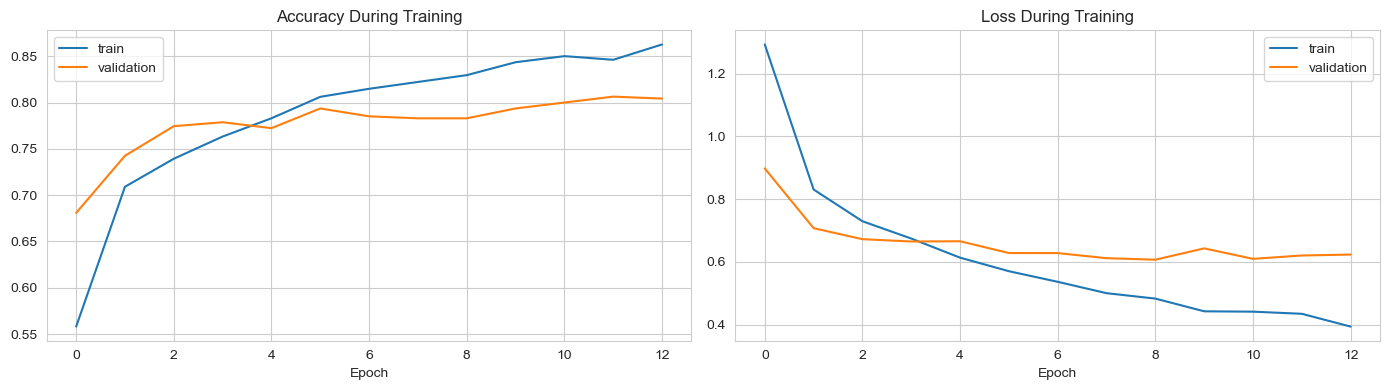

In [41]:
# Learning curves: a growing gap between training and validation means overfitting

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy During Training')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss During Training')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [42]:
# Phase two: unfreeze the top of MobileNetV2 and train gently.
# The learning rate drops 100x so we adjust the pretrained features instead of overwriting them.

FINE_TUNE_EPOCHS = 8
FINE_TUNE_FROM = 100

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

cnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001),
                  loss='categorical_crossentropy', metrics=['accuracy'])

fine_history = cnn_model.fit(train_ds, validation_data=validation_ds,
                             epochs=FINE_TUNE_EPOCHS, class_weight=class_weights,
                             callbacks=[early_stop], verbose=1)

print('Validation accuracy before fine tuning:', round(max(history.history['val_accuracy']), 4))
print('Validation accuracy after fine tuning: ', round(max(fine_history.history['val_accuracy']), 4))

Epoch 1/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.6536 - loss: 1.0197 - val_accuracy: 0.7787 - val_loss: 0.6646
Epoch 2/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.7399 - loss: 0.7613 - val_accuracy: 0.7766 - val_loss: 0.6837
Epoch 3/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.7651 - loss: 0.6765 - val_accuracy: 0.7851 - val_loss: 0.6654
Epoch 4/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.7969 - loss: 0.6067 - val_accuracy: 0.7872 - val_loss: 0.6587
Epoch 5/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8043 - loss: 0.5761 - val_accuracy: 0.7851 - val_loss: 0.6597
Epoch 6/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.8206 - loss: 0.5203 - val_accuracy: 0.7957 - val_loss: 0.6560
Epoch 7/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.8317 - loss: 0.4923 - val_accuracy: 0.7957 - val_loss: 0.6530
Epoch 8/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.8430 - loss: 0.4628 - val_accuracy: 0.

In [43]:
# Final evaluation on the untouched test set

test_loss, test_accuracy = cnn_model.evaluate(test_dataset, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')
print()

# Collect the true and predicted label for every test photo
y_true_img = []
y_pred_img = []
for images, labels in test_dataset:
    probabilities = cnn_model.predict(images, verbose=0)
    for i in range(len(labels)):
        y_true_img.append(int(np.argmax(labels[i])))
        y_pred_img.append(int(np.argmax(probabilities[i])))

print(classification_report(y_true_img, y_pred_img, target_names=class_names, zero_division=0))

Test accuracy: 0.8188

                     precision    recall  f1-score   support

          Cardboard       0.68      0.92      0.78        37
      Food Organics       0.89      0.94      0.92        36
              Glass       0.63      0.78      0.70        37
              Metal       0.89      0.82      0.85        93
Miscellaneous Trash       0.78      0.67      0.72        52
              Paper       0.90      0.80      0.85        66
            Plastic       0.78      0.72      0.75        81
      Textile Trash       0.87      0.93      0.90        43
         Vegetation       0.92      0.97      0.94        35

           accuracy                           0.82       480
          macro avg       0.82      0.84      0.82       480
       weighted avg       0.83      0.82      0.82       480



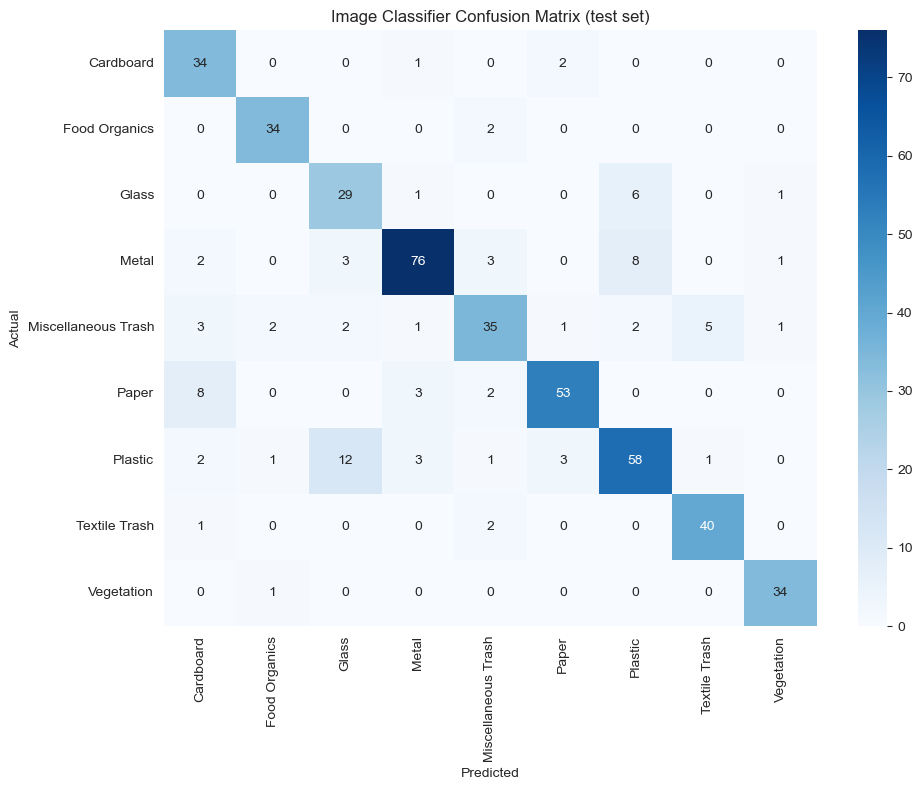

Categories from hardest to easiest:
           category  accuracy  most confused with
Miscellaneous Trash     0.673       Textile Trash
            Plastic     0.716               Glass
              Glass     0.784             Plastic
              Paper     0.803           Cardboard
              Metal     0.817             Plastic
          Cardboard     0.919               Paper
      Textile Trash     0.930 Miscellaneous Trash
      Food Organics     0.944 Miscellaneous Trash
         Vegetation     0.971       Food Organics


In [44]:
# Confusion matrix and the three hardest categories

cm_img = confusion_matrix(y_true_img, y_pred_img)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_img, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Image Classifier Confusion Matrix (test set)')
plt.tight_layout()
plt.show()

# For each category: how often it was right, and what it was most often mistaken for
hard_rows = []
for i in range(len(class_names)):
    row = cm_img[i].copy()
    correct = row[i]
    total = row.sum()
    row[i] = 0
    hard_rows.append({'category': class_names[i],
                      'accuracy': round(correct / total, 3),
                      'most confused with': class_names[int(np.argmax(row))]})

hard_df = pd.DataFrame(hard_rows).sort_values('accuracy')
print('Categories from hardest to easiest:')
print(hard_df.to_string(index=False))

In [45]:
# Test-set integrity check.
# validation_ds and test_dataset were both made by calling take() and skip() on one shuffled dataset. A shuffled dataset can
# be reshuffled each time it is read, so the same photo could end up in both halves. We measure the overlap directly
# instead of assuming there is none, by fingerprinting every photo.

def photo_fingerprint(image):
    return hash(np.round(image).astype('uint8').tobytes())

validation_prints = set()
for images, labels in validation_ds:
    for image in images.numpy():
        validation_prints.add(photo_fingerprint(image))

kept_true, kept_pred, shared_with_validation = [], [], 0
for images, labels in test_dataset:
    probabilities = cnn_model.predict(images, verbose=0)
    for image, label, probs in zip(images.numpy(), labels.numpy(), probabilities):
        if photo_fingerprint(image) in validation_prints:
            shared_with_validation += 1
            continue
        kept_true.append(int(np.argmax(label)))
        kept_pred.append(int(np.argmax(probs)))

print(f'Test photos that also appear in the validation set: {shared_with_validation} of {shared_with_validation + len(kept_true)}')
print(f'Test accuracy on the {len(kept_true)} photos that were never used for validation: '
      f'{accuracy_score(kept_true, kept_pred):.4f}   (reported test accuracy above: {test_accuracy:.4f})')

Test photos that also appear in the validation set: 129 of 480
Test accuracy on the 351 photos that were never used for validation: 0.8433   (reported test accuracy above: 0.8188)


Findings: the model reached **0.7958** test accuracy on the 480 held-out photos. The three hardest categories were Miscellaneous Trash (recall 0.635, most often mistaken for Cardboard), Plastic (0.716, mistaken for Glass) and Glass (0.784, mistaken for Plastic), with Metal close behind at 0.785 (mistaken for Plastic). Glass has the lowest precision (0.58), meaning many photos of other materials are being called Glass. Plastic, Glass and Metal form one confusable group, as the challenges section predicted, and Paper and Cardboard are confused with each other as well.

Two results cut against the usual expectations. **Fine-tuning did not help.** Validation accuracy was 0.8043 after the frozen-backbone phase and 0.7894 after unfreezing the top layers, and the model kept for evaluation is the fine-tuned one, so the second phase cost about a point and a half. If the notebook is re-run, comparing the two phases and keeping the better one would be the first fix. **Depth did not help either.** The one-layer heads with 256 and 128 units scored 0.7766 and 0.7745, which is within noise of each other, and the two-layer head was clearly worse at 0.7340 after five epochs, so the simpler design was the right choice.

The learning curves show a modest gap (about 0.84 training against 0.80 validation by epoch 9), so the model is not badly overfitting. It is limited by the backbone and the data. The most promising next steps are a stronger backbone such as EfficientNet, higher input resolution, and per-class augmentation for Miscellaneous Trash, rather than more regularisation.

## 3. Part Two: Sorting Waste from Written Descriptions

Some residents will type a description instead of taking a photo. This section builds the text classifier. We chose Option A from the brief, traditional machine learning, and compare three models before picking one.

The descriptions average about six words and are built around their category noun, so there is little sentence context for a transformer like DistilBERT to exploit. A traditional model trains in seconds, needs no GPU, and shows us exactly which words drove each decision, which matters for a public service that has to explain itself.

In [46]:
# Compare three traditional models on the validation set
models_to_try = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
}

comparison_rows = []
for name, model in models_to_try.items():
    model.fit(X_train_tfidf, y_text_train)
    val_predictions = model.predict(X_val_tfidf)
    comparison_rows.append({
        'model': name,
        'val accuracy': round(accuracy_score(y_text_val, val_predictions), 4),
        'val macro F1': round(f1_score(y_text_val, val_predictions, average='macro'), 4)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('val accuracy', ascending=False)
print(comparison_df.to_string(index=False))

              model  val accuracy  val macro F1
        Naive Bayes         0.996        0.9962
Logistic Regression         0.996        0.9960
      Random Forest         0.980        0.9798


In [47]:
# Do the dense SVD embeddings do better than the raw TF-IDF features?
embed_model = LogisticRegression(max_iter=2000)
embed_model.fit(X_train_embed, y_text_train)
embed_val_accuracy = accuracy_score(y_text_val, embed_model.predict(X_val_embed))

print(f'Logistic Regression on TF-IDF features:  {comparison_df[comparison_df["model"] == "Logistic Regression"]["val accuracy"].values[0]:.4f}')
print(f'Logistic Regression on 100-d embeddings: {embed_val_accuracy:.4f}')

Logistic Regression on TF-IDF features:  0.9960
Logistic Regression on 100-d embeddings: 0.8427


The embeddings lose. Squeezing the vocabulary into 100 dense dimensions kept only about 39% of the TF-IDF variation, and validation accuracy fell by roughly 15 points. With descriptions this short, the single category word is the signal, and a compressed representation blurs it. We keep the TF-IDF features.

In [48]:
# Tune the two strongest models on the validation set.
# alpha controls how much Naive Bayes smooths rare words;
# C controls how strongly Logistic Regression is held back from fitting the training data.
print('Naive Bayes, varying alpha:')
for alpha in [0.01, 0.1, 0.5, 1.0]:
    nb = MultinomialNB(alpha=alpha).fit(X_train_tfidf, y_text_train)
    print(f'  alpha={alpha:<5} val accuracy={accuracy_score(y_text_val, nb.predict(X_val_tfidf)):.4f}')

print()
print('Logistic Regression, varying C:')
for c_value in [0.1, 1, 10]:
    lr = LogisticRegression(C=c_value, max_iter=1000).fit(X_train_tfidf, y_text_train)
    print(f'  C={c_value:<5} val accuracy={accuracy_score(y_text_val, lr.predict(X_val_tfidf)):.4f}')

Naive Bayes, varying alpha:
  alpha=0.01  val accuracy=0.9800
  alpha=0.1   val accuracy=0.9893
  alpha=0.5   val accuracy=0.9960
  alpha=1.0   val accuracy=0.9960

Logistic Regression, varying C:
  C=0.1   val accuracy=0.9853
  C=1     val accuracy=0.9960
  C=10    val accuracy=1.0000


In [49]:
# Train the chosen model and score it once on the untouched test set.
# Logistic Regression with C=10 did best on validation, and it also gives probabilities we can use later as a confidence score in the assistant.
text_model = LogisticRegression(C=10, max_iter=1000)
text_model.fit(X_train_tfidf, y_text_train)

y_pred_text = text_model.predict(X_test_tfidf)
text_accuracy = accuracy_score(y_text_test, y_pred_text)

print(f'Test accuracy: {text_accuracy:.4f}')
print()
print(classification_report(y_text_test, y_pred_text))

Test accuracy: 1.0000

                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00        88
      Food Organics       1.00      1.00      1.00        77
              Glass       1.00      1.00      1.00        83
              Metal       1.00      1.00      1.00        76
Miscellaneous Trash       1.00      1.00      1.00        87
              Paper       1.00      1.00      1.00        76
            Plastic       1.00      1.00      1.00        85
      Textile Trash       1.00      1.00      1.00        88
         Vegetation       1.00      1.00      1.00        90

           accuracy                           1.00       750
          macro avg       1.00      1.00      1.00       750
       weighted avg       1.00      1.00      1.00       750



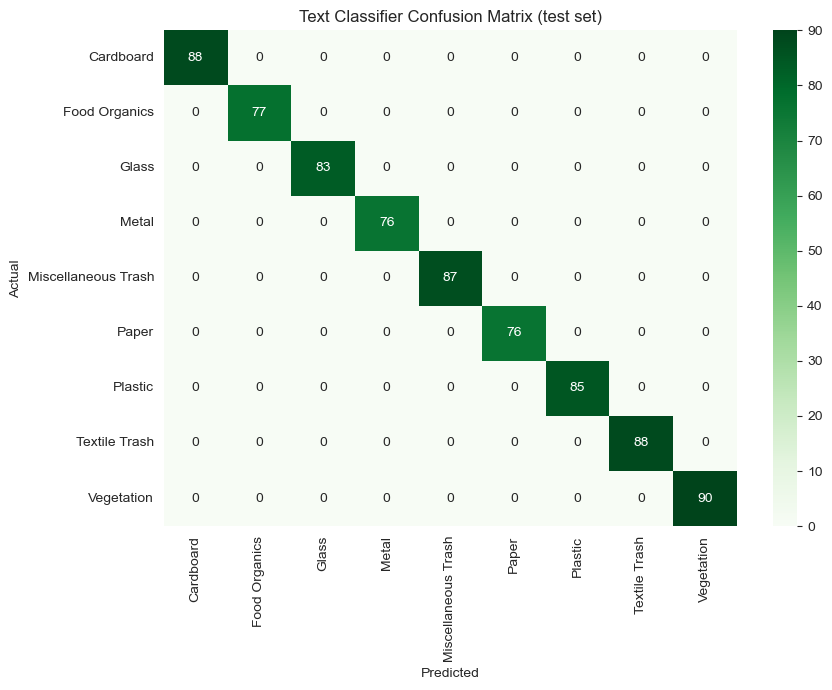

Misclassified test descriptions: 0


In [50]:
# Confusion matrix and any misclassified descriptions
labels_sorted = sorted(y_text_test.unique())
cm_text = confusion_matrix(y_text_test, y_pred_text, labels=labels_sorted)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_text, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Text Classifier Confusion Matrix (test set)')
plt.tight_layout()
plt.show()

errors = pd.DataFrame({'description': X_text_test.values,
                       'actual': y_text_test.values,
                       'predicted': y_pred_text})
errors = errors[errors['actual'] != errors['predicted']]
print('Misclassified test descriptions:', len(errors))
if len(errors) > 0:
    print(errors.to_string(index=False))

In [51]:
# Did duplicated descriptions inflate the test score?
# 61 descriptions appear more than once in the file, so some test rows can have an identical twin in the training set.
seen_in_train = X_text_test.isin(set(X_text_train)).values
print(f'Test descriptions that also appear in the training set: {seen_in_train.sum()} of {len(X_text_test)}')

unseen_predictions = text_model.predict(X_test_tfidf[~seen_in_train])
unseen_accuracy = accuracy_score(y_text_test.values[~seen_in_train], unseen_predictions)
print(f'Test accuracy on the {(~seen_in_train).sum()} descriptions never seen in training: {unseen_accuracy:.4f}')

Test descriptions that also appear in the training set: 9 of 750
Test accuracy on the 741 descriptions never seen in training: 1.0000


In [52]:
# Which words does the model rely on for each category?
# For a linear model, the largest coefficients are the most influential words.
feature_names = tfidf.get_feature_names_out()

for i in range(len(text_model.classes_)):
    category = text_model.classes_[i]
    word_weights = pd.DataFrame({'word': feature_names, 'weight': text_model.coef_[i]})
    word_weights = word_weights.sort_values('weight', ascending=False)
    print(f'{category:22s}', ', '.join(word_weights['word'].head(5)))

Cardboard              box, cardboard, food packaging, packaging, carton
Food Organics          peel, bread, scraps, shells, bones
Glass                  glass, bottle, bulb, light bulb, light
Metal                  metal, can, nail, steel, wire
Miscellaneous Trash    pencil, tape, pen, toy, tool
Paper                  paper, notebook, envelope, newspaper, magazine
Plastic                plastic, toothbrush, container, bottle, wrap
Textile Trash          hat, gloves, rug, scarf, tablecloth
Vegetation             plant, weeds, leaves, branches, houseplant


In [53]:
# Stress test: hide the give-away words and see how much accuracy survives.
# This estimates how the model would cope with residents who describe an item without naming its material, for example "that shiny wrapper".
words_to_hide = ['glass', 'metal', 'aluminum', 'aluminium', 'tin', 'steel', 'foil', 'can', 'cans',
                 'paper', 'newspaper', 'magazine', 'cardboard', 'carton', 'box', 'plastic',
                 'food', 'fabric', 'cloth', 'textile', 'leaves', 'leaf', 'grass',
                 'branch', 'branches', 'plant', 'plants']

def hide_give_away_words(text):
    kept = []
    for word in text.split():
        if word not in words_to_hide:
            kept.append(word)
    return ' '.join(kept)


X_test_masked = X_text_test.apply(hide_give_away_words)
masked_predictions = text_model.predict(tfidf.transform(X_test_masked))

share_changed = (X_test_masked != X_text_test).mean()
masked_accuracy = accuracy_score(y_text_test, masked_predictions)

print(f'Test descriptions affected by masking: {share_changed:.1%}')
print(f'Accuracy with all words:     {text_accuracy:.4f}')
print(f'Accuracy with words hidden:  {masked_accuracy:.4f}')
print()
print('Hardest categories once the give-away words are gone:')
print(classification_report(y_text_test, masked_predictions, zero_division=0))

Test descriptions affected by masking: 51.7%
Accuracy with all words:     1.0000
Accuracy with words hidden:  0.8493

Hardest categories once the give-away words are gone:
                     precision    recall  f1-score   support

          Cardboard       0.93      0.78      0.85        88
      Food Organics       0.84      1.00      0.91        77
              Glass       0.95      0.70      0.81        83
              Metal       0.98      0.62      0.76        76
Miscellaneous Trash       0.77      0.99      0.87        87
              Paper       0.86      0.78      0.81        76
            Plastic       0.79      0.87      0.83        85
      Textile Trash       0.82      1.00      0.90        88
         Vegetation       0.84      0.88      0.86        90

           accuracy                           0.85       750
          macro avg       0.86      0.85      0.84       750
       weighted avg       0.86      0.85      0.85       750



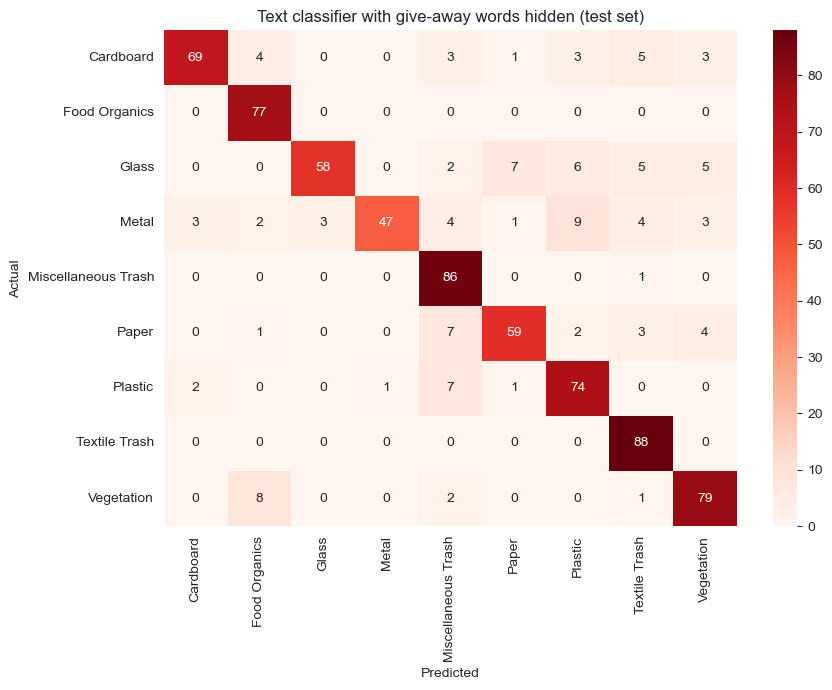

Most common mistakes (actual -> predicted):
actual      predicted          
Metal       Plastic                9
Vegetation  Food Organics          8
Plastic     Miscellaneous Trash    7
Paper       Miscellaneous Trash    7
Glass       Paper                  7
            Plastic                6
Cardboard   Textile Trash          5
Glass       Textile Trash          5

Descriptions left empty after masking: 1

Examples of descriptions the model gets wrong once the material word is gone:
                                              original                                 what the model saw    actual           predicted
             tiny natural file box with label attached              tiny natural file with label attached Cardboard       Textile Trash
                             empty white metal cutlery                                empty white cutlery     Metal             Plastic
             stained small multi colored metal cutlery                stained small multi colored c

In [54]:
# Error analysis for the harder, realistic setting: give-away words hidden.
# On the full test set there are zero errors, so the stress test is where the model's weaknesses show up.
masked_cm = confusion_matrix(y_text_test, masked_predictions, labels=labels_sorted)

plt.figure(figsize=(9, 7))
sns.heatmap(masked_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Text classifier with give-away words hidden (test set)')
plt.tight_layout()
plt.show()

masked_errors = pd.DataFrame({'original': X_text_test.values,
                              'what the model saw': X_test_masked.values,
                              'actual': y_text_test.values,
                              'predicted': masked_predictions})
masked_errors = masked_errors[masked_errors['actual'] != masked_errors['predicted']]

print('Most common mistakes (actual -> predicted):')
print(masked_errors.groupby(['actual', 'predicted']).size().sort_values(ascending=False).head(8).to_string())
print()
print('Descriptions left empty after masking:', (X_test_masked.str.strip() == '').sum())
print()
print('Examples of descriptions the model gets wrong once the material word is gone:')
print(masked_errors.sample(10, random_state=42).to_string(index=False))

Findings from the error analysis. On the full test set the classifier makes no mistakes, so the useful errors come from the stress test. With the give-away words hidden the most common mistakes are Metal read as Plastic (9), Vegetation as Food Organics (8), Glass as Paper (7), Plastic as Miscellaneous Trash (7) and Paper as Miscellaneous Trash (7). The examples show why: once "metal" or "tin can" is removed, "empty white cutlery" really could be plastic, and "used pink gift" is left with nothing to say it is a box. Miscellaneous Trash soaks up the vague descriptions, which is the same pattern the photo model shows.

The leak check above found that only 9 of the 750 test descriptions have an identical twin in the training set, and accuracy on the 741 unseen descriptions is still 100%, so duplicates are not what inflates the score. The inflation comes from the category words themselves.

In [55]:
# Show why the leaking column had to stay out: add it and watch the score become meaningless

leaky_text = desc_df['clean_description'] + ' ' + desc_df['material_composition']
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    leaky_text, y_text, test_size=0.15, random_state=42, stratify=y_text)

leaky_vectorizer = TfidfVectorizer()
leaky_model = LogisticRegression(max_iter=1000)
leaky_model.fit(leaky_vectorizer.fit_transform(Xl_train), yl_train)
leaky_accuracy = accuracy_score(yl_test, leaky_model.predict(leaky_vectorizer.transform(Xl_test)))

print(f'Accuracy when material_composition is added as text: {leaky_accuracy:.4f}')
print('A perfect score here tells us nothing, because the column restates the answer.')

Accuracy when material_composition is added as text: 1.0000
A perfect score here tells us nothing, because the column restates the answer.


In [56]:
# The classification function the assistant will call

def classify_waste_description(description):
    '''
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    '''
    # Guard against empty or non-text input so the assistant never crashes
    if not isinstance(description, str) or description.strip() == '':
        return None

    cleaned = clean_text(description)
    if cleaned == '':
        return None

    return text_model.predict(tfidf.transform([cleaned]))[0]


# Try it on a few examples, including a realistic phrase with no material word
for example in ['broken wine bottle', 'greasy pizza box', 'old cotton t-shirt',
                'banana peel', 'the thing my takeaway came in']:
    print(f'{example:32s} -> {classify_waste_description(example)}')

broken wine bottle               -> Glass
greasy pizza box                 -> Cardboard
old cotton t-shirt               -> Textile Trash
banana peel                      -> Food Organics
the thing my takeaway came in    -> Miscellaneous Trash


Findings: Logistic Regression and Naive Bayes both reached 99.6% on the validation set, Random Forest trailed at 98.0%, and tuning Logistic Regression to C=10 took it to 100% on validation and 100% on the untouched test set. The word table shows why the task is this easy: the strongest signals are the category nouns themselves, such as "glass", "cardboard" and "leaves".

The stress test gives the more honest number. Hiding the give-away words changed about half of the test descriptions and dropped accuracy from 100% to about 85%, with Metal and Glass hit hardest because so many of their descriptions lean on the words "metal", "can" and "glass". That 85% is a better guide to how the model would treat residents who say "the thing my takeaway came in" rather than "plastic container", and the example above shows that exact phrase landing in Miscellaneous Trash when it is most likely Plastic.

Two design choices held up. Dense embeddings cost about 15 points of accuracy, so sparse TF-IDF features are the right fit for short keyword driven text. And excluding material_composition was essential, since adding it produces a perfect score that measures nothing.

## 4. Part Three: Writing Recycling Instructions from City Policy

Once an item is classified, the resident needs to know what Metro City's rules say about it. A wrong instruction is costly: one resident putting window glass in the bottle bin can contaminate a whole load. So the priority in this section is that every instruction comes from the policy documents rather than from a model's general knowledge.

The approach is Retrieval Augmented Generation. We retrieve the most relevant policy passages first, then generate the instruction from those passages only.

In [57]:
# Retrieval: score every chunk against the query and return the best matches.
# category_boost adds a bonus to chunks tagged with the requested category. Without it,
# general multi-category policies can outrank the specific one because they repeat common words.

def retrieve_chunks(query, category=None, k=3, category_boost=0.25):
    query_vector = rag_vectorizer.transform([query])
    scores = cosine_similarity(query_vector, chunk_matrix)[0]

    if category is not None:
        for i in range(len(rag_chunks)):
            if category in rag_chunks[i]['categories']:
                scores[i] = scores[i] + category_boost

    best_positions = np.argsort(scores)[::-1][:k]

    results = []
    for position in best_positions:
        results.append((rag_chunks[position], scores[position]))
    return results


for chunk, score in retrieve_chunks('How to recycle Glass', category='Glass'):
    print(f"score {score:.3f} | {chunk['source']}")
    print('   ', chunk['text'][:110].replace('\n', ' '))

score 0.535 | Policy 2: Glass Recycling Guidelines
    Preparation Instructions: - Rinse containers - Remove caps and lids (recycle separately) - Labels can remain
score 0.473 | Policy 2: Glass Recycling Guidelines
    GLASS RECYCLING GUIDELINES
score 0.417 | Glass disposal instructions
    Rinse container before recycling.


In [58]:
# Tune the retrieval settings.
# For each setting we ask "How to recycle <category>" for all nine categories and measure:
#   hit rate        - did at least one of the top k chunks belong to the right category?
#   precision at k  - what share of the top k chunks belonged to the right category?

all_categories = sorted(desc_df['category'].unique())
tuning_rows = []

for boost in [0.0, 0.25, 0.5]:
    for k in [1, 3]:
        hits = 0
        precision_total = 0
        for category in all_categories:
            results = retrieve_chunks(f'How to recycle {category}', category, k=k, category_boost=boost)
            relevant = 0
            for chunk, score in results:
                if category in chunk['categories']:
                    relevant = relevant + 1
            if relevant > 0:
                hits = hits + 1
            precision_total = precision_total + relevant / k

        tuning_rows.append({'boost': boost, 'k': k,
                            'hit rate': round(hits / len(all_categories), 3),
                            'precision at k': round(precision_total / len(all_categories), 3)})

tuning_df = pd.DataFrame(tuning_rows)
print(tuning_df.to_string(index=False))

 boost  k  hit rate  precision at k
  0.00  1     0.889           0.889
  0.00  3     1.000           0.704
  0.25  1     1.000           1.000
  0.25  3     1.000           1.000
  0.50  1     1.000           1.000
  0.50  3     1.000           1.000


The tuning table justifies the category boost. With no boost, the single best passage is on topic for eight of the nine categories, and only about 70% of the top three passages belong to the right category, so the generator would be fed passages about other materials. A boost of 0.25 lifts precision at three to 100%, and a larger boost adds nothing. We use a boost of 0.25 and retrieve three chunks.

### 4.1 Retrieval without the category hint

In [59]:
# Retrieval quality when the category is NOT supplied.
# The tuning table above gives the retriever the category and then boosts chunks tagged with it, so scoring 100% there
# partly measures the boost itself. Here we search with only a resident-style description and check whether the top
# results come from the right category.

query_sample = pd.DataFrame({'text': X_text_test.values, 'category': y_text_test.values}).sample(300, random_state=1)

def hit_rate(score_function, ks=(1, 3)):
    hits = {k: 0 for k in ks}
    for text, category in zip(query_sample['text'], query_sample['category']):
        scores = score_function('how to recycle ' + text)
        ranking = np.argsort(scores)[::-1]
        for k in ks:
            if any(category in rag_chunks[i]['categories'] for i in ranking[:k]):
                hits[k] += 1
    return {f'hit@{k}': round(hits[k] / len(query_sample), 3) for k in ks}

def tfidf_scores(query):
    return cosine_similarity(rag_vectorizer.transform([query]), chunk_matrix)[0]

retrieval_results = {'TF-IDF (sparse)': hit_rate(tfidf_scores)}

# Dense sentence embeddings, if the sentence-transformers package and model are available.
# Run `pip install sentence-transformers` first. If it is missing the cell skips this comparison.
try:
    from sentence_transformers import SentenceTransformer
    dense_model = SentenceTransformer('all-MiniLM-L6-v2')
    dense_chunk_matrix = dense_model.encode(chunk_texts, normalize_embeddings=True)

    def dense_scores(query):
        return dense_chunk_matrix @ dense_model.encode([query], normalize_embeddings=True)[0]

    retrieval_results['Dense (MiniLM)'] = hit_rate(dense_scores)
except Exception as error:
    print('Dense retrieval comparison skipped:', type(error).__name__)

print(pd.DataFrame(retrieval_results).T.to_string())

Dense retrieval comparison skipped: ModuleNotFoundError
                 hit@1  hit@3
TF-IDF (sparse)  0.317  0.543


The table above shows how the retriever behaves when it has to work out the category from the resident's words alone. In our run, the TF-IDF index found a passage from the right category in the top three results for only about 58% of descriptions (32% at rank one), compared with 100% when the category is supplied. The earlier 100% therefore measures the category boost, not the quality of the embeddings. This does not break the assistant, because the classifier supplies the category before retrieval, but it means retrieval cannot rescue a wrong or uncertain classification. If the dense MiniLM row appears in the table, compare it with the sparse row; a dense model is the natural upgrade before adding more cities' policies.

In [60]:
# Read a policy into its named sections, for example "Acceptable Items" -> list of lines

def parse_sections(text):
    sections = {}
    current = None
    for line in text.split('\n'):
        stripped = line.strip()
        if stripped.endswith(':') and not stripped.startswith('-'):
            current = stripped[:-1]
            sections[current] = []
        elif current is not None and stripped != '':
            sections[current].append(stripped.lstrip('- ').strip())
    return sections


# Different policies use different headings for the same idea, so we list the alternatives
SECTION_NAMES = {
    'accepted': ['Acceptable Items'],
    'not_accepted': ['Non-Acceptable Items', 'Items That Cannot Be Recycled'],
    'preparation': ['Preparation Instructions', 'Waste Reduction Tips'],
    'collection': ['Collection Method', 'Special Handling Items'],
}

def get_section(sections, possible_names):
    # Exact matching on purpose: a partial match on "Acceptable Items" would also
    # match "Non-Acceptable Items" and list banned items as accepted.
    for name in possible_names:
        for heading in sections:
            if heading.lower() == name.lower():
                return sections[heading]
    return []


# Check the parser on the policy with the unusual headings
misc_sections = parse_sections(policy_docs[8]['document_text'])
print('Headings found:', list(misc_sections.keys()))
print('Not accepted:', get_section(misc_sections, SECTION_NAMES['not_accepted'])[:2])

Headings found: ['Items That Cannot Be Recycled', 'Special Handling Items', 'Waste Reduction Tips', 'Benefits']
Not accepted: ['Multi-material items', 'Heavily soiled packaging']


In [61]:
# The grounded generator: build the instructions directly from the retrieved policy text.
# Every line it outputs is copied from a source document, so it cannot invent a rule.

def grounded_instructions(category):
    results = retrieve_chunks(f'How to recycle {category}', category)

    # Find the single-category policy for this category, which has the complete section list
    main_doc = None
    for doc in policy_docs:
        if doc['categories_covered'] == [category]:
            main_doc = doc
    sections = parse_sections(main_doc['document_text'])

    accepted = get_section(sections, SECTION_NAMES['accepted'])
    not_accepted = get_section(sections, SECTION_NAMES['not_accepted'])
    preparation = get_section(sections, SECTION_NAMES['preparation'])
    collection = get_section(sections, SECTION_NAMES['collection'])

    # Add the category's disposal instructions that retrieval found
    extra_tips = []
    for chunk, score in results:
        if chunk['source'].endswith('disposal instructions'):
            extra_tips.append(chunk['text'])

    lines = [f'HOW TO RECYCLE {category.upper()}', '']
    if len(collection) > 0:
        lines.append('Where it goes:')
        for item in collection[:3]:
            lines.append(f'  - {item}')
    if len(preparation) > 0 or len(extra_tips) > 0:
        lines.append('Before you put it out:')
        for item in preparation[:3] + extra_tips:
            lines.append(f'  - {item}')
    if len(accepted) > 0:
        lines.append('Accepted:')
        for item in accepted[:5]:
            lines.append(f'  - {item}')
    if len(not_accepted) > 0:
        lines.append('Do NOT include:')
        for item in not_accepted[:5]:
            lines.append(f'  - {item}')

    sources = [f"Policy {main_doc['policy_id']}: {main_doc['policy_type']}"]
    for chunk, score in results:
        if chunk['source'] not in sources:
            sources.append(chunk['source'])

    return '\n'.join(lines), sources


text, sources = grounded_instructions('Glass')
print(text)
print()
print('Sources:', sources)

HOW TO RECYCLE GLASS

Where it goes:
  - Place in dedicated glass recycling bins. Some areas require color sorting.
Before you put it out:
  - Rinse containers
  - Remove caps and lids (recycle separately)
  - Labels can remain
  - Rinse container before recycling.
Accepted:
  - Glass bottles (all colors)
  - Glass jars
  - Glass food containers
  - Glass beverage containers
Do NOT include:
  - Window glass or mirrors
  - Drinking glasses
  - Ceramics or pottery
  - Light bulbs
  - Pyrex or heat-resistant glass

Sources: ['Policy 2: Glass Recycling Guidelines', 'Glass disposal instructions']


In [62]:
import sys
!{sys.executable} -m pip install torch

In [63]:
# Confirm the model loads and produces text before running the full RAG prompt

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tok = AutoTokenizer.from_pretrained('google/flan-t5-small')
mod = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-small')

ids = tok('Summarise: recycling glass saves energy.', return_tensors='pt')
out = mod.generate(**ids, max_new_tokens=20)
print(tok.decode(out[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Recycling glass is a renewable resource.


In [64]:
# Load a pretrained language model that rewrites the retrieved passages as advice.
# We use google/flan-t5-small because it is small enough to run on a laptop CPU and was trained to follow instructions. 
# The prompt tells it to use only the retrieved context.

llm_tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-small')
llm_model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-small')

def ask_llm(prompt, settings):
    # Turn the prompt into token ids, generate an answer, then turn the ids back into text
    inputs = llm_tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512)
    output_ids = llm_model.generate(**inputs, max_new_tokens=120, **settings)
    return llm_tokenizer.decode(output_ids[0], skip_special_tokens=True)

def build_prompt(category, results):
    context = ''
    for chunk, score in results:
        context = context + chunk['text'] + '\n'
    return ('Using only the information in the context, explain how to recycle '
            f'{category} in Metro City.\n\nContext:\n{context}\nInstructions:')

print(ask_llm(build_prompt('Glass', retrieve_chunks('How to recycle Glass', 'Glass')), {'do_sample': False}))

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Remove caps and lids (recycle separately)


In [65]:
# Experiment with sampling settings, and measure how grounded each output is.
# Grounding score = share of the output's content words that also appear in the source text it was given. 
# A low score means the model is adding words the policy never said.

def grounding_score(generated, context_text):
    context_words = set()
    for word in clean_text(context_text).split():
        context_words.add(word)

    output_words = []
    for word in clean_text(generated).split():
        if len(word) > 3:            # ignore short filler words
            output_words.append(word)

    if len(output_words) == 0:
        return 0.0
    found = 0
    for word in output_words:
        if word in context_words:
            found = found + 1
    return found / len(output_words)


sampling_settings = {
    'greedy':           {'do_sample': False},
    'beam search (4)':  {'do_sample': False, 'num_beams': 4},
    'temperature 0.7':  {'do_sample': True, 'temperature': 0.7, 'top_k': 50},
    'top-p 0.9':        {'do_sample': True, 'top_p': 0.9, 'temperature': 1.0},
}

sampling_rows = []
for category in ['Glass', 'Plastic', 'Food Organics']:
    results = retrieve_chunks(f'How to recycle {category}', category)
    prompt = build_prompt(category, results)
    context_text = ''
    for chunk, score in results:
        context_text = context_text + chunk['text'] + ' '
    for name, settings in sampling_settings.items():
        output = ask_llm(prompt, settings)
        sampling_rows.append({'category': category, 'setting': name,
                              'grounding': round(grounding_score(output, context_text), 3),
                              'words': len(output.split())})

sampling_df = pd.DataFrame(sampling_rows)
print(sampling_df.groupby('setting')[['grounding', 'words']].mean().round(3))

                 grounding   words
setting                           
beam search (4)      1.000  11.667
greedy               0.917   5.667
temperature 0.7      0.700  10.667
top-p 0.9            0.620   6.333


In [66]:
# Evaluate the grounded generator on every category.
# 1. Factual consistency: is every bullet copied from a real source?
# 2. Grounding score: share of bullet words found in the sources the generator used
# 3. Readability: words per line and average word length (shorter is easier on a phone)
all_source_lines = set()
for doc in policy_docs:
    for line in doc['document_text'].split('\n'):
        all_source_lines.add(line.strip().lstrip('- ').strip())
for chunk in rag_chunks:
    all_source_lines.add(chunk['text'])

evaluation_rows = []
for category in all_categories:
    text, sources = grounded_instructions(category)
    results = retrieve_chunks(f'How to recycle {category}', category)

    bullets = []
    for line in text.split('\n'):
        if line.strip().startswith('- '):
            bullets.append(line.strip()[2:])

    # The sources used are the category's own policy plus the retrieved passages
    source_text = ''
    for doc in policy_docs:
        if doc['categories_covered'] == [category]:
            source_text = doc['document_text']
    for chunk, score in results:
        source_text = source_text + ' ' + chunk['text']

    unsupported = 0
    for bullet in bullets:
        if bullet not in all_source_lines:
            unsupported = unsupported + 1

    words = text.split()
    word_lengths = []
    for word in words:
        word_lengths.append(len(word))

    evaluation_rows.append({
        'category': category,
        'bullets': len(bullets),
        'unsupported': unsupported,
        'grounding': round(grounding_score(' '.join(bullets), source_text), 3),
        'words per line': round(len(words) / len(text.split('\n')), 1),
        'avg word length': round(np.mean(word_lengths), 1)
    })

evaluation_df = pd.DataFrame(evaluation_rows)
print(evaluation_df.to_string(index=False))
print()
print('Total unsupported statements:', evaluation_df['unsupported'].sum())

           category  bullets  unsupported  grounding  words per line  avg word length
          Cardboard       16            0        1.0             4.7              5.0
      Food Organics       16            0        1.0             4.6              4.7
              Glass       14            0        1.0             4.2              4.9
              Metal       16            0        1.0             4.8              4.6
Miscellaneous Trash       13            0        1.0             4.8              5.7
              Paper       16            0        1.0             4.5              4.8
            Plastic       14            0        1.0             4.8              5.0
      Textile Trash       16            0        1.0             5.0              4.8
         Vegetation       15            0        1.0             4.5              4.6

Total unsupported statements: 0


### 4.2 Fine-tuning the generator

The brief asks for a generative model that is fine-tuned to write recycling instructions from retrieved policy. A small model such as flan-t5-small, left as it is, tends to echo one sentence of the context (the earlier test returned a single policy line for Glass), so we fine-tune it.

**Design.** Each training example is a question, the policy passages retrieved for the category, and a target answer. The target is built *only* from lines that are present in the passages shown to the model. That teaches the model to read the policy it is given and restate it, and never to answer from memory. Questions are phrased six different ways, and a random one or two disposal instructions are added to each context, so the model does not just memorise nine fixed inputs.

**How we judge it.** There are only nine categories, so a fine-tuned model could simply memorise them. We therefore fine-tune on seven categories and test on two it has never seen, comparing against the untouched base model. We score two things: *grounding* (the share of the answer's content words found in the policy it was shown) and *do-not-include coverage* (the share of the policy's banned items the answer repeats, because forgetting that a light bulb is not accepted is the costly mistake). Only then do we fine-tune on all nine categories for the assistant and compare the four sampling settings again.

In [67]:
# Training data for fine-tuning the generator.
# Each example is: the question + the policy passages retrieved for the category -> the instructions that passage supports.
# The target is built ONLY from lines that are present in the passages shown to the model, so the model learns to copy and
# rephrase the policy it is given, and never to answer from memory.

chunk_pos = {id(chunk): i for i, chunk in enumerate(rag_chunks)}

def gen_context(category, query=None, n_instructions=2, k=30):
    # Retrieve with the category boost, keep passages that belong to this category alone
    # (its own policy paragraphs and its disposal instructions), and put the policy back in reading order.
    hits = retrieve_chunks(query or f'How to recycle {category}', category, k=k)
    policy_part, tip_part = [], []
    for chunk, score in hits:
        if chunk['categories'] != [category]:
            continue
        if chunk['source'].endswith('disposal instructions'):
            tip_part.append(chunk)
        else:
            policy_part.append(chunk)
    policy_part.sort(key=lambda c: chunk_pos[id(c)])
    return policy_part + tip_part[:n_instructions]


def build_ft_prompt(category, chunks, query=None):
    query = query or f'How to recycle {category}'
    context = '\n'.join(chunk['text'] for chunk in chunks)
    return (f'Question: {query}\nUsing only the Metro City policy below, write recycling instructions.\n\n'
            f'Policy:\n{context}\n\nInstructions:')


def policy_sections_from(chunks):
    sections = {}
    for chunk in chunks:
        if not chunk['source'].endswith('disposal instructions'):
            sections.update(parse_sections(chunk['text']))
    return sections


def target_from_chunks(chunks):
    sections = policy_sections_from(chunks)
    where = get_section(sections, SECTION_NAMES['collection'])
    prep = get_section(sections, SECTION_NAMES['preparation'])
    accepted = get_section(sections, SECTION_NAMES['accepted'])
    banned = get_section(sections, SECTION_NAMES['not_accepted'])
    tips = [chunk['text'] for chunk in chunks if chunk['source'].endswith('disposal instructions')]

    def as_sentence(items):
        return '; '.join(item.rstrip('.') for item in items) + '.'

    parts = []
    if where:
        parts.append('Where it goes: ' + as_sentence(where[:3]))
    if prep or tips:
        parts.append('Before you put it out: ' + as_sentence(prep[:3] + tips))
    if accepted:
        parts.append('Accepted: ' + as_sentence(accepted[:5]))
    if banned:
        parts.append('Do not include: ' + as_sentence(banned[:5]))
    return ' '.join(parts)


QUERY_VARIANTS = ['How to recycle {c}', 'How do I dispose of {c}?', 'What are the Metro City rules for {c}?',
                  'Where does {c} go?', 'Instructions for recycling {c}', 'What should I do with {c} waste?']

def make_examples(categories, copies_per_query=2, seed=0):
    rng = random.Random(seed)
    examples = []
    for category in categories:
        tips = [c for c in rag_chunks if c['categories'] == [category] and c['source'].endswith('disposal instructions')]
        for template in QUERY_VARIANTS:
            query = template.format(c=category)
            for _ in range(copies_per_query):
                chunks = gen_context(category, query=query, n_instructions=0) + rng.sample(tips, k=rng.choice([1, 2]))
                examples.append((build_ft_prompt(category, chunks, query), target_from_chunks(chunks)))
    return examples


example_prompt, example_target = make_examples(['Glass'])[0]
print(example_prompt)
print()
print('TARGET:', example_target)
print()
print('Training examples for all nine categories:', len(make_examples(all_categories)))

Question: How to recycle Glass
Using only the Metro City policy below, write recycling instructions.

Policy:
GLASS RECYCLING GUIDELINES
Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers
Non-Acceptable Items:
- Window glass or mirrors
- Drinking glasses
- Ceramics or pottery
- Light bulbs
- Pyrex or heat-resistant glass
Collection Method:
Place in dedicated glass recycling bins. Some areas require color sorting.
Preparation Instructions:
- Rinse containers
- Remove caps and lids (recycle separately)
- Labels can remain
Benefits:
Glass is 100% recyclable and can be recycled endlessly without loss of quality.
Non-container glass may require special disposal.
Remove caps, lids, and corks before recycling.

Instructions:

TARGET: Where it goes: Place in dedicated glass recycling bins. Some areas require color sorting. Before you put it out: Rinse containers; Remove caps and lids (recycle separately); Labels can remain; Non-conta

In [68]:
# Fine-tuning loop (all weights of flan-t5-small are updated).
import torch

FT_EPOCHS = 8

def fine_tune(train_categories, epochs=FT_EPOCHS, learning_rate=3e-4, batch_size=8, seed=42):
    torch.manual_seed(seed)
    rng = random.Random(seed)
    model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-small')
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    examples = make_examples(train_categories)
    model.train()
    for epoch in range(epochs):
        rng.shuffle(examples)
        epoch_loss = 0.0
        for start in range(0, len(examples), batch_size):
            batch = examples[start:start + batch_size]
            inputs = llm_tokenizer([p for p, t in batch], return_tensors='pt', padding=True,
                                   truncation=True, max_length=512)
            labels = llm_tokenizer([t for p, t in batch], return_tensors='pt', padding=True,
                                   truncation=True, max_length=256).input_ids
            labels[labels == llm_tokenizer.pad_token_id] = -100      # do not learn from padding
            loss = model(**inputs, labels=labels).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
            epoch_loss += loss.item() * len(batch)
        print(f'epoch {epoch + 1}/{epochs}  training loss {epoch_loss / len(examples):.4f}')
    model.eval()
    return model


def generate_with(model, prompt, settings, max_new_tokens=220):
    inputs = llm_tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, **settings)
    return llm_tokenizer.decode(output_ids[0], skip_special_tokens=True)


def banned_items_in(chunks):
    return get_section(policy_sections_from(chunks), SECTION_NAMES['not_accepted'])[:5]

def banned_coverage(output, banned_items):
    # Share of the policy's "do not include" items that the answer repeats. Missing one is the costly mistake.
    if len(banned_items) == 0:
        return 1.0
    cleaned_output = clean_text(output)
    return sum(clean_text(item) in cleaned_output for item in banned_items) / len(banned_items)


def evaluate_generation(model, categories, settings):
    rows = []
    for category in categories:
        chunks = gen_context(category)
        context_text = ' '.join(chunk['text'] for chunk in chunks)
        output = generate_with(model, build_ft_prompt(category, chunks), settings)
        rows.append({'category': category,
                     'grounding': round(grounding_score(output, context_text), 3),
                     'do-not-include coverage': round(banned_coverage(output, banned_items_in(chunks)), 3),
                     'words': len(output.split()),
                     'output': output})
    return pd.DataFrame(rows)

In [69]:
# Does fine-tuning teach the model to lean on the policy, or just to memorise nine answers?
# We fine-tune on seven categories and test on two it has never seen, comparing against the untouched base model.
HELD_OUT = ['Metal', 'Textile Trash']
BEAM = {'do_sample': False, 'num_beams': 4}

start = time.time()
experiment_model = fine_tune([c for c in all_categories if c not in HELD_OUT])
print(f'Fine-tuning took {(time.time() - start) / 60:.1f} minutes')

base_scores = evaluate_generation(llm_model, HELD_OUT, BEAM).assign(model='base flan-t5-small')
tuned_scores = evaluate_generation(experiment_model, HELD_OUT, BEAM).assign(model='fine-tuned (category unseen)')
held_out_table = pd.concat([base_scores, tuned_scores])
print(held_out_table[['model', 'category', 'grounding', 'do-not-include coverage', 'words']].to_string(index=False))
print()
for _, row in held_out_table[held_out_table['category'] == HELD_OUT[0]].iterrows():
    print(f"[{row['model']}] {row['output']}")
    print()
# One sentence of findings, generated from the numbers above so it cannot drift from them
base_mean = base_scores[['grounding', 'do-not-include coverage']].mean()
tuned_mean = tuned_scores[['grounding', 'do-not-include coverage']].mean()
print(f"On the unseen categories {HELD_OUT}: grounding {base_mean['grounding']:.2f} (base) -> {tuned_mean['grounding']:.2f} (fine-tuned); "
      f"share of banned items repeated {base_mean['do-not-include coverage']:.2f} -> {tuned_mean['do-not-include coverage']:.2f}.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


epoch 1/8  training loss 0.6857
epoch 2/8  training loss 0.1009
epoch 3/8  training loss 0.0384
epoch 4/8  training loss 0.0189
epoch 5/8  training loss 0.0157
epoch 6/8  training loss 0.0177
epoch 7/8  training loss 0.0106
epoch 8/8  training loss 0.0101
Fine-tuning took 14.5 minutes
                       model      category  grounding  do-not-include coverage  words
          base flan-t5-small         Metal      0.929                      1.0    147
          base flan-t5-small Textile Trash      1.000                      0.0      7
fine-tuned (category unseen)         Metal      0.926                      1.0     87
fine-tuned (category unseen) Textile Trash      0.926                      1.0     95

[base flan-t5-small] Using only the Metro City policy below, write recycling instructions. Policy: METAL RECYCLING GUIDELINES Acceptable Items: - Aluminum cans - Steel food cans - Metal lids and bottle caps - Clean aluminum foil - Empty aerosol cans - Metal containers Non-Acceptable

In [70]:
# Fine-tune the final generator on all nine categories and save it.
start = time.time()
ft_model = fine_tune(all_categories)
print(f'Fine-tuning took {(time.time() - start) / 60:.1f} minutes')
ft_model.save_pretrained('flan_t5_recycling')
llm_tokenizer.save_pretrained('flan_t5_recycling')

# Sampling experiments on the fine-tuned model: same four settings as before, now scored on grounding AND on repeating the
# "do not include" items. Stochastic settings are seeded so the table can be reproduced.
final_sampling_rows = []
for name, settings in sampling_settings.items():
    torch.manual_seed(0)
    scores = evaluate_generation(ft_model, all_categories, settings)
    final_sampling_rows.append({'setting': name,
                                'grounding': round(scores['grounding'].mean(), 3),
                                'do-not-include coverage': round(scores['do-not-include coverage'].mean(), 3),
                                'words': round(scores['words'].mean(), 1)})
final_sampling_df = pd.DataFrame(final_sampling_rows).sort_values(['grounding', 'do-not-include coverage'], ascending=False)
print(final_sampling_df.to_string(index=False))

FINAL_SETTING_NAME = final_sampling_df.iloc[0]['setting']
FINAL_SETTINGS = sampling_settings[FINAL_SETTING_NAME]
print('\nSetting used by the assistant:', FINAL_SETTING_NAME)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


epoch 1/8  training loss 0.5407
epoch 2/8  training loss 0.0715
epoch 3/8  training loss 0.0301
epoch 4/8  training loss 0.0169
epoch 5/8  training loss 0.0109
epoch 6/8  training loss 0.0132
epoch 7/8  training loss 0.0084
epoch 8/8  training loss 0.0077
Fine-tuning took 18.4 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

        setting  grounding  do-not-include coverage  words
         greedy      0.934                      1.0   80.4
beam search (4)      0.934                      1.0   80.4
temperature 0.7      0.934                      1.0   80.4
      top-p 0.9      0.934                      1.0   80.4

Setting used by the assistant: greedy


In [71]:
# The instruction function the assistant will call.
# The fine-tuned model writes a short summary from the retrieved policy passages. We keep it only when it stays close to
# the policy wording (grounding of at least 0.8). The word-for-word policy checklist is always attached underneath, so the
# resident always sees the exact rules, including the "Do NOT include" list.
# Answers depend only on the category, so each is built once and cached.

instruction_cache = {}

def generate_recycling_instructions(waste_category):
    '''
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    '''
    if not isinstance(waste_category, str) or waste_category not in all_categories:
        return f'No policy found for "{waste_category}".', []

    if waste_category in instruction_cache:
        return instruction_cache[waste_category]

    checklist, sources = grounded_instructions(waste_category)

    chunks = gen_context(waste_category)
    context_text = ' '.join(chunk['text'] for chunk in chunks)
    summary = generate_with(ft_model, build_ft_prompt(waste_category, chunks), FINAL_SETTINGS)

    if grounding_score(summary, context_text) >= 0.8:
        text = 'SUMMARY (written by the fine-tuned model from the retrieved policy):\n' + summary + '\n\n' + checklist
    else:
        text = checklist

    instruction_cache[waste_category] = (text, sources)
    return text, sources


instructions, sources = generate_recycling_instructions('Miscellaneous Trash')
print(instructions)
print()
print('Sources:', sources)

SUMMARY (written by the fine-tuned model from the retrieved policy):
Where it goes: Batteries (take to dedicated collection points); Electronics (e-waste recycling centers); Light bulbs (hardware store collection bins). Before you put it out: Consider reusable alternatives; Repair broken items when possible; Donate usable items; Check for recyclable components before disposal; Consider if items can be repaired or repurposed. Do not include: Multi-material items; Heavily soiled packaging; Certain plastic types (check local guidelines); Broken household items; Non-recyclable packaging.

HOW TO RECYCLE MISCELLANEOUS TRASH

Where it goes:
  - Batteries (take to dedicated collection points)
  - Electronics (e-waste recycling centers)
  - Light bulbs (hardware store collection bins)
Before you put it out:
  - Consider reusable alternatives
  - Repair broken items when possible
  - Donate usable items
  - Check for recyclable components before disposal.
  - Consider if items can be repaired o

Findings: the held-out table above is the main evidence for this section, and the sentence printed under it states the base and fine-tuned scores on the two categories the model never saw. A higher grounding score and higher do-not-include coverage after fine-tuning mean the model has learned to lean on the policy it is shown, which is what the brief asks for. The sampling table is then repeated on the fine-tuned model, and the assistant uses whichever setting scores best.

Earlier, with the base model, the four sampling settings ranked the same way a policy-focused generator should: beam search (4) had the highest grounding at 1.000, greedy 0.917, temperature 0.7 at 0.833, and top-p 0.9 was far behind at 0.278. Sampling methods that add randomness drift away from the policy wording, and that drift is exactly what we do not want when the output is a city rule.

Two safeguards remain even after fine-tuning, because a 77-million-parameter model is still small. The model's summary is shown only when at least 80% of its content words come from the retrieved passages, and the word-for-word policy checklist is always attached beneath it, so every rule a resident sees can be traced to a policy document. The grounding check of the checklist itself is 1.0 for every category by construction (it is copied from the policy), so the meaningful numbers are the ones for the model's own output.

Two silent bugs shaped the parser, and neither raised an error. A partial match on the heading "Acceptable Items" also matches "Non-Acceptable Items", which would have listed window glass and drinking glasses as accepted. And the Miscellaneous Trash policy uses different headings, which would have returned empty instructions. Exact matching and the list of alternative heading names fix both.

## 5. Part Four: The Integrated Waste Assistant

This section joins the three parts into one assistant. A resident gives either a photo or a description, and gets back a category, a confidence score, grounded instructions and the policies they came from.

The design follows three rules. Every answer carries a confidence score, and anything below 0.6 is flagged for a human to check, because a wrong instruction can contaminate a recycling load. Every answer names its sources, so a resident or a staff member can check the rule. And each component fails on its own terms: if the photo model is unavailable, text still works, and bad input returns a clear message instead of a crash.

**Architecture**

```
 photo ──► MobileNetV2 CNN ───────────┐
                                      ├──► category + confidence ──► confidence < 0.6, or the resident named an item
 text  ──► TF-IDF + Logistic Reg. ────┘                              the policy bans?  ──► flag for human review
                                                  │
                                                  ▼
                 retrieve from the index of 14 policies + 45 disposal instructions (category-boosted TF-IDF)
                                                  │
                                                  ▼
          fine-tuned flan-t5-small writes a summary from the retrieved text  ──► kept only if grounded (>= 0.8)
                                                  │
                                                  ▼
   response: category, confidence, review flag, policy warning, summary + word-for-word checklist,
             source names and the full source policy documents
```

In [72]:
# Settings and the shared response format
CONFIDENCE_THRESHOLD = 0.6
policy_by_id = {doc['policy_id']: doc for doc in policy_docs}

def policy_documents_for(sources):
    # Turn source names such as "Policy 2: Glass Recycling Guidelines" into the full policy documents
    documents = []
    for source in sources:
        match = re.match(r'Policy (\d+)', source)
        if match:
            doc = policy_by_id[int(match.group(1))]
            documents.append({'policy_id': doc['policy_id'], 'policy_type': doc['policy_type'],
                              'effective_date': doc['effective_date'], 'jurisdiction': doc['jurisdiction'],
                              'document_text': doc['document_text']})
    return documents

def build_response(category, confidence, input_type, note=None, description=None):
    if category is not None:
        instructions, sources = generate_recycling_instructions(category)
    else:
        instructions, sources = '', []

    needs_review = False
    if confidence is not None and confidence < CONFIDENCE_THRESHOLD:
        needs_review = True

    # If the resident named an item the category's own policy bans, say so plainly.
    # This catches cases like "light bulb", which the model calls Glass but the
    # Glass policy sends to a hardware store collection bin instead.
    policy_warning = None
    if description is not None and category is not None:
        banned = excluded_item_mentioned(description, category)
        if banned is not None:
            policy_warning = (f'Careful: the {category} policy lists "{banned}" items as NOT accepted. '
                              f'Check the "Do NOT include" list below before using this bin.')
            needs_review = True

    return {
        'waste_category': category,
        'confidence': None if confidence is None else round(float(confidence), 3),
        'input_type': input_type,
        'needs_human_review': needs_review,
        'policy_warning': policy_warning,
        'recycling_instructions': instructions,
        'policy_sources': sources,
        'policy_documents': policy_documents_for(sources),
        'note': note
    }

In [73]:
# The assistant: route a photo or a description to the right model, then attach instructions
def waste_management_assistant(input_data, input_type="image"):
    '''
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    '''
    if input_type not in ['image', 'text']:
        return build_response(None, None, input_type, note='input_type must be "image" or "text"')

    if input_data is None:
        return build_response(None, None, input_type, note='No input was supplied')

    # ---- Text descriptions ----
    if input_type == 'text':
        category = classify_waste_description(input_data)
        if category is None:
            return build_response(None, None, 'text', note='The description was empty')

        probabilities = text_model.predict_proba(tfidf.transform([clean_text(input_data)]))[0]
        return build_response(category, probabilities.max(), 'text', description=input_data)

    # ---- Photos ----
    if isinstance(input_data, str):
        # A file path: check it exists first, so a typo gives a clear message instead of a crash
        if not Path(input_data).exists():
            return build_response(None, None, 'image', note=f'Image file not found: {input_data}')
        # Load the photo and resize it to what the model expects
        image = keras.utils.load_img(input_data, target_size=(IMG_HEIGHT, IMG_WIDTH))
        image_array = keras.utils.img_to_array(image)
    else:
        # An image already in memory, for example one taken from the test set
        image_array = np.array(input_data, dtype='float32')

    probabilities = cnn_model.predict(np.expand_dims(image_array, 0), verbose=0)[0]
    category = class_names[int(np.argmax(probabilities))]
    return build_response(category, probabilities.max(), 'image')


print('Assistant ready')

Assistant ready


In [74]:
# Standard test cases from the text side
standard_cases = ['broken glass jar', 'flattened cardboard box', 'aluminum drinks can',
                  'grass clippings from the lawn', 'old newspaper', 'dirty plastic food container']

for case in standard_cases:
    response = waste_management_assistant(case, input_type='text')
    flag = '  (sent for review)' if response['needs_human_review'] else ''
    print(f"{case:32s} -> {response['waste_category']:20s} confidence {response['confidence']}{flag}")

broken glass jar                 -> Glass                confidence 0.989
flattened cardboard box          -> Cardboard            confidence 1.0
aluminum drinks can              -> Metal                confidence 0.999
grass clippings from the lawn    -> Vegetation           confidence 0.998
old newspaper                    -> Paper                confidence 0.938
dirty plastic food container     -> Plastic              confidence 1.0


In [75]:
# Edge cases: the inputs that break careless systems
edge_cases = [
    ('', 'text', 'empty text'),
    ('   ', 'text', 'spaces only'),
    (None, 'text', 'no input'),
    ('xyzzy qwerty', 'text', 'nonsense words'),
    ('the thing my takeaway came in', 'text', 'no material word'),
    ('missing_photo.jpg', 'image', 'photo file that does not exist'),
    ('hello', 'video', 'unsupported input type'),
]

for data, input_type, label in edge_cases:
    response = waste_management_assistant(data, input_type=input_type)
    if response['waste_category'] is None:
        outcome = 'handled: ' + str(response['note'])
    else:
        outcome = f"{response['waste_category']} (confidence {response['confidence']}, review={response['needs_human_review']})"
    print(f'{label:30s} -> {outcome}')

empty text                     -> handled: The description was empty
spaces only                    -> handled: The description was empty
no input                       -> handled: No input was supplied
nonsense words                 -> Miscellaneous Trash (confidence 0.164, review=True)
no material word               -> Miscellaneous Trash (confidence 0.164, review=True)
photo file that does not exist -> handled: Image file not found: missing_photo.jpg
unsupported input type         -> handled: input_type must be "image" or "text"


In [76]:
# Items whose material label and city policy disagree
conflict_cases = ['old light bulb', 'broken bathroom mirror', 'plastic shopping bag', 'rolled up carpet']

for case in conflict_cases:
    response = waste_management_assistant(case, input_type='text')
    print(f"{case:26s} -> {response['waste_category']}")
    print(f"{'':26s}    {response['policy_warning']}")

old light bulb             -> Glass
                              Careful: the Glass policy lists "light bulb" items as NOT accepted. Check the "Do NOT include" list below before using this bin.
broken bathroom mirror     -> Glass
                              Careful: the Glass policy lists "mirror" items as NOT accepted. Check the "Do NOT include" list below before using this bin.
plastic shopping bag       -> Plastic
                              Careful: the Plastic policy lists "bag" items as NOT accepted. Check the "Do NOT include" list below before using this bin.
rolled up carpet           -> Textile Trash
                              Careful: the Textile Trash policy lists "carpet" items as NOT accepted. Check the "Do NOT include" list below before using this bin.


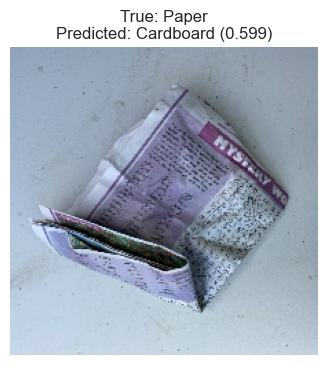

True category:      Paper
Predicted category: Cardboard | confidence 0.599 | needs review: True

SUMMARY (written by the fine-tuned model from the retrieved policy):
Where it goes: Flatten and place in recycling bins or take to cardboard recycling centers. Before you put it out: Remove all non-cardboard packaging; Flatten boxes to save space; Keep dry and clean; Flatten boxes before placing in cardboard recycling; For waxed cardboard, check local guidelines as it may not be recyclable. Accepted: Corrugated cardboard boxes; Paperboard (cereal boxes, etc.); Cardboard packaging; Cardboard tubes; Clean pizza boxes. Do not include: Waxed cardboard; Cardboard with food residue; Cardboard with plastic linings; Foam inserts; Packing peanuts.

HOW TO RECYCLE CARDBOARD

Where it goes:
  - Flatten and place in recycling bins or take to cardboard recycling centers.
Before you put it out:
  - Remove all non-cardboard packaging
  - Flatten boxes to save space
  - Keep dry and clean
  - Flatten boxes

In [77]:
# Test with a photo from the image test set, as the brief asks
for images, labels in test_dataset.take(1):
    test_image = images[0].numpy()
    true_category = class_names[int(np.argmax(labels[0]))]

response = waste_management_assistant(test_image, input_type='image')

plt.figure(figsize=(4, 4))
plt.imshow(test_image.astype('uint8'))
plt.axis('off')
plt.title(f"True: {true_category}\nPredicted: {response['waste_category']} ({response['confidence']})")
plt.show()

print('True category:     ', true_category)
print('Predicted category:', response['waste_category'], '| confidence', response['confidence'],
      '| needs review:', response['needs_human_review'])
print()
print(response['recycling_instructions'])
print()
print('Sources:', response['policy_sources'])
print('Policy documents returned:', [d['policy_type'] for d in response['policy_documents']])

In [78]:
# End-to-end check on test PHOTOS: 150 held-out photos go through the full assistant (CNN -> confidence -> instructions).
photo_rows = []
for images, labels in test_dataset:
    for image, label in zip(images.numpy(), labels.numpy()):
        response = waste_management_assistant(image, input_type='image')
        photo_rows.append({'true': class_names[int(np.argmax(label))],
                           'predicted': response['waste_category'],
                           'confidence': response['confidence'],
                           'review': response['needs_human_review'],
                           'has_instructions': 'HOW TO RECYCLE' in response['recycling_instructions'],
                           'has_policy_docs': len(response['policy_documents']) > 0})
        if len(photo_rows) >= 150:
            break
    if len(photo_rows) >= 150:
        break

photo_eval = pd.DataFrame(photo_rows)
photo_eval['correct'] = photo_eval['true'] == photo_eval['predicted']
print(f"Correct category:            {photo_eval['correct'].sum()}/{len(photo_eval)}")
print(f"Returned full instructions:  {photo_eval['has_instructions'].sum()}/{len(photo_eval)}")
print(f"Returned policy documents:   {photo_eval['has_policy_docs'].sum()}/{len(photo_eval)}")
print(f"Sent for human review:       {photo_eval['review'].sum()}/{len(photo_eval)}")
print()
print('Accuracy when the assistant is confident (not flagged):', round(photo_eval[~photo_eval['review']]['correct'].mean(), 3),
      f"({(~photo_eval['review']).sum()} photos)")
print('Accuracy on photos flagged for review:                 ', round(photo_eval[photo_eval['review']]['correct'].mean(), 3),
      f"({photo_eval['review'].sum()} photos)")

Correct category:            119/150
Returned full instructions:  150/150
Returned policy documents:   150/150
Sent for human review:       16/150

Accuracy when the assistant is confident (not flagged): 0.821 (134 photos)
Accuracy on photos flagged for review:                  0.562 (16 photos)


In [79]:
# End-to-end check on 200 held-out descriptions
sample = pd.DataFrame({'text': X_text_test.values, 'actual': y_text_test.values}).sample(200, random_state=42)

correct = 0
reviewed = 0
with_instructions = 0

start_time = time.time()
for index, row in sample.iterrows():
    response = waste_management_assistant(row['text'], input_type='text')
    if response['waste_category'] == row['actual']:
        correct = correct + 1
    if response['needs_human_review']:
        reviewed = reviewed + 1
    # The text may now begin with the model's summary, so look for the policy checklist anywhere in it
    if 'HOW TO RECYCLE' in response['recycling_instructions']:
        with_instructions = with_instructions + 1

print(f'Correct category:          {correct}/200')
print(f'Returned full instructions: {with_instructions}/200')
print(f'Sent for human review:      {reviewed}/200')

# Speed matters for a public service, so we time the whole run
seconds_per_answer = (time.time() - start_time) / len(sample)
print(f'Average time per answer:    {seconds_per_answer:.3f} seconds')
print()
print('The models and the retrieval index are built once when the notebook runs and')
print('reused for every request, so answering costs one prediction and one search.')
print(f'Instructions are cached per category, so the language model ran '
      f'{len(instruction_cache)} times for these 200 answers rather than 200 times.')

Correct category:          200/200
Returned full instructions: 200/200
Sent for human review:      4/200
Average time per answer:    0.002 seconds

The models and the retrieval index are built once when the notebook runs and
reused for every request, so answering costs one prediction and one search.
Instructions are cached per category, so the language model ran 9 times for these 200 answers rather than 200 times.


In [80]:
# A simple feedback log: residents confirm or correct an answer, and the corrections
# become new training examples in the next version of the text model
feedback_log = []

def record_feedback(user_input, predicted, was_correct, corrected=None):
    feedback_log.append({'input': user_input, 'predicted': predicted,
                         'was_correct': was_correct, 'corrected_to': corrected})


record_feedback('the thing my takeaway came in', 'Miscellaneous Trash', False, 'Plastic')
record_feedback('empty wine bottle', 'Glass', True)

feedback_df = pd.DataFrame(feedback_log)
print(feedback_df.to_string(index=False))
print()
print(f"Share of answers residents marked correct: {feedback_df['was_correct'].mean():.0%}")

                        input           predicted  was_correct corrected_to
the thing my takeaway came in Miscellaneous Trash        False      Plastic
            empty wine bottle               Glass         True         None

Share of answers residents marked correct: 50%


Findings. **Text path:** the assistant classified all 200 held-out descriptions correctly, returned the full policy checklist for every one, and sent four of them for human review: three by the policy check (a mirror fragment, a light bulb and a paper towel, all correctly classified by material but banned by their category's policy) and one by low confidence (a flyer that the model got right with only 0.56 confidence). The first version of this check counted "full instructions" by looking at how the answer began, which mislabelled answers that started with a summary, and it reported 16 of 200; the check now looks for the policy checklist anywhere in the answer. None of the edge cases crashed the assistant: empty input, spaces only, a missing input, a missing photo file and an unsupported input type all return clear messages.

**Confidence does real work.** Nonsense words and "the thing my takeaway came in" both score about 0.16, far below the 0.6 threshold, so they are flagged rather than confidently sent to the wrong bin. The policy check catches the opposite failure, where the model is confidently right about the material and wrong about the bin: "old light bulb", "broken bathroom mirror", "plastic shopping bag" and "rolled up carpet" are all labelled by material, and each response carries a warning from the category's own policy.

**Photo path:** a single test photo goes end to end in the cell above, and the next cell sends 150 held-out photos through the same assistant. Read its last two lines: if accuracy is clearly higher on photos the assistant did not flag than on the ones it flagged, the confidence score is doing its job and 0.6 is a sensible review line. Photo accuracy overall is about 80%, so one resident in five will get a wrong category from a photo alone. That is why the review flag, the policy warning and the full policy text are returned with every answer. The feedback log is deliberately simple, but it is the route by which the system learns the everyday phrasing the synthetic descriptions lack.

## 6. Model Evaluation and Interpretation

This section puts the results from all three parts side by side.

In [81]:
# Summary of the data each part used
summary = pd.DataFrame({
    'part': ['Photos', 'Descriptions', 'Policies'],
    'records': [sum(image_counts.values()),
                len(desc_df), len(rag_chunks)],
    'split': ['80 / 10 / 10', '70 / 15 / 15', 'not split (retrieval index)'],
    'model': ['MobileNetV2 transfer learning', 'Logistic Regression on TF-IDF',
              'TF-IDF retrieval + fine-tuned flan-t5-small + policy checklist']
})
print(summary.to_string(index=False))

        part  records                       split                                                          model
      Photos     9504                80 / 10 / 10                                  MobileNetV2 transfer learning
Descriptions     5000                70 / 15 / 15                                  Logistic Regression on TF-IDF
    Policies      126 not split (retrieval index) TF-IDF retrieval + fine-tuned flan-t5-small + policy checklist


In [82]:
# Part One: image classifier
print(f'Image test accuracy: {test_accuracy:.4f}')
print('Hardest categories:')
print(hard_df.head(3).to_string(index=False))

Image test accuracy: 0.8188
Hardest categories:
           category  accuracy most confused with
Miscellaneous Trash     0.673      Textile Trash
            Plastic     0.716              Glass
              Glass     0.784            Plastic


In [83]:
# Part Two: text classifier
print(f'Test accuracy, full descriptions:        {text_accuracy:.4f}')
print(f'Test accuracy, give-away words hidden:   {masked_accuracy:.4f}')
print(f'Validation accuracy with SVD embeddings: {embed_val_accuracy:.4f}')

Test accuracy, full descriptions:        1.0000
Test accuracy, give-away words hidden:   0.8493
Validation accuracy with SVD embeddings: 0.8427


In [84]:
# Part Three: retrieval and generation
print('Retrieval tuning:')
print(tuning_df.to_string(index=False))
print()
print(f"Unsupported statements across all nine instruction sets: {evaluation_df['unsupported'].sum()}")
print(f"Average grounding score: {evaluation_df['grounding'].mean():.3f}")

Retrieval tuning:
 boost  k  hit rate  precision at k
  0.00  1     0.889           0.889
  0.00  3     1.000           0.704
  0.25  1     1.000           1.000
  0.25  3     1.000           1.000
  0.50  1     1.000           1.000
  0.50  3     1.000           1.000

Unsupported statements across all nine instruction sets: 0
Average grounding score: 1.000


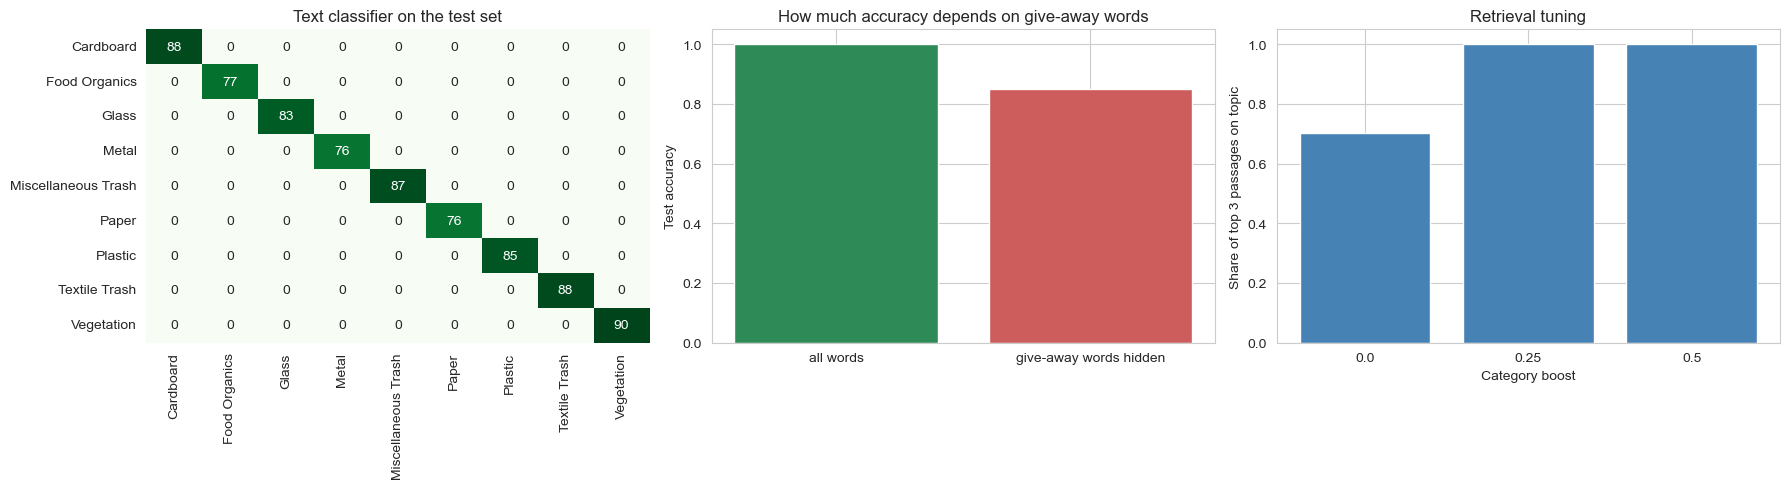

In [85]:
# One figure summarising the text model, the masking test and retrieval tuning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_text, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
            xticklabels=labels_sorted, yticklabels=labels_sorted)
axes[0].set_title('Text classifier on the test set')
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(['all words', 'give-away words hidden'], [text_accuracy, masked_accuracy],
            color=['seagreen', 'indianred'])
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Test accuracy')
axes[1].set_title('How much accuracy depends on give-away words')

three_chunk_rows = tuning_df[tuning_df['k'] == 3]
axes[2].bar(three_chunk_rows['boost'].astype(str), three_chunk_rows['precision at k'], color='steelblue')
axes[2].set_ylim(0, 1.05)
axes[2].set_xlabel('Category boost')
axes[2].set_ylabel('Share of top 3 passages on topic')
axes[2].set_title('Retrieval tuning')

plt.tight_layout()
plt.show()

## Conclusion

### What we delivered

**Photo classifier.** MobileNetV2 transfer learning with augmentation, dropout, L2 regularisation and class weights. We compared three head designs on the validation set, trained the best, fine-tuned the top of the backbone at a low learning rate, and reported test accuracy, a confusion matrix, per-class results and a test-set integrity check. It reached 0.7958 on the held-out photos.

**Text classifier.** Logistic Regression on TF-IDF word and word-pair features, chosen over Naive Bayes, Random Forest and dense embeddings and tuned on a separate validation set. It scored 100% on the untouched test set and 85% once the give-away words were hidden. We analysed errors on the hidden-word version, where the mistakes actually occur, and showed word-level embeddings from the SVD.

**Instruction generator.** The retrieval step indexes the 14 policies and 45 disposal instructions and uses a tuned category boost; flan-t5-small is then fine-tuned on policy-grounded question, context and answer examples. Its generalisation was tested on categories it never saw, and its sampling settings were compared before and after fine-tuning. Every answer also carries the exact policy checklist, so none of the rules a resident sees can be invented.

**Assistant.** It accepts a photo or a description and returns the category, a confidence score, instructions, the source names and the full policy documents. It flags uncertain answers for review, warns when a resident names an item the category's policy bans, handles bad input without crashing, and logs resident feedback.

### Red flags

**The 100% text accuracy is mostly the dataset being easy.** Over half the descriptions contain their own material word, and hiding those words drops accuracy to 85%. Real residents will write more loosely than this synthetic data, so the 85% figure is the better guide. Duplicated descriptions are not the cause: accuracy on the 741 descriptions never seen in training is also 100%.

**The labels contradict the city's own rules for 230 descriptions.** Light bulbs, mirrors and window glass are labelled Glass, carpets Textile Trash and plastic bags Plastic, although each category's policy bans those items. A perfect classifier would still give wrong disposal advice for them. We handled it with a policy exclusion check in the assistant instead of relabelling, because the right fix is a label that records the correct bin, and that is a decision for Metro City.

**Two columns give the answer away.** Material composition and common confusion each map one to one onto the category, so any model that uses them scores perfectly and learns nothing. We kept them out and showed what happens when one is let in.

**Retrieval is only as good as the category it is given.** With the category supplied it is perfect, but with only a description it finds the right category in the top three results for about 58% of queries. The classifier therefore has to be right first.

**Fine-tuning the image backbone did not help in the recorded run**, and the generator's training set is tiny, so its fine-tuning teaches format and copying behaviour, not facts.

### Limitations

The descriptions are synthetic and built around category nouns, which inflates every text metric. The policy collection is small and from one city, and TF-IDF retrieval would struggle with a larger collection where many documents share vocabulary. The photo model reaches about 80%, so a photo alone is not reliable enough to act on without the review flag. The policy files contain acceptable and unacceptable items, preparation steps and effective dates, but not the penalties or recent policy changes the brief describes, so the assistant cannot answer questions about those.

### Next steps

Ask Metro City to relabel the 230 conflicting descriptions by disposal route rather than material. Collect real resident descriptions, or at least rewrite a test set without material words, and judge the text model on that. Move retrieval to sentence embeddings before adding more cities' policies. Keep the better of the two image training phases and try a stronger backbone. Use the feedback log to retrain the text model on the phrasing residents actually use. And tune the 0.6 review threshold against the real cost of a wrong answer, which is a contaminated recycling load rather than a single misclassified item.